# 9_multivariable_crime_weather_socioeconomic_analysis

This notebook builds a **district-time panel** that combines:

- crime data
- weather data
- socio-economic data
- economic data

and then runs several forms of multivariable analysis to answer:

> Which weather, socio-economic, and economic factors are associated with higher crime levels in Los Angeles?

This notebook is designed to fit the structure of your repository:

- `processed_data/merged_weather_crime_districts_data.csv`
- `raw_data/socio_economic_data_2010.csv`
- `raw_data/economic_data.csv`

## Recommended interpretation

The most defensible unit of analysis here is:

- **district × day** for weather effects
- with **static socio-economic variables** merged by district
- and **time-varying economic variables** merged by month or quarter

That lets you study both:
1. short-run weather relationships
2. longer-run area-level socioeconomic relationships

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_context("talk")

## 1. Paths and helpers

In [2]:
BASE = Path("..")
if not (BASE / "processed_data").exists():
    # fallback if notebook is run from repo root
    BASE = Path(".")

PROCESSED = BASE / "processed_data"
RAW = BASE / "raw_data"

crime_weather_path = PROCESSED / "merged_weather_crime_districts_data.csv"
socio_path = RAW / "socio_economic_data_2010.csv"
econ_path = RAW / "economic_data.csv"

print("Using base path:", BASE.resolve())
print("Crime + weather:", crime_weather_path)
print("Socioeconomic:", socio_path)
print("Economic:", econ_path)

Using base path: D:\Users\Miljana\Documents\Projects+\SIAP\LA-Crime-Analysis
Crime + weather: ..\processed_data\merged_weather_crime_districts_data.csv
Socioeconomic: ..\raw_data\socio_economic_data_2010.csv
Economic: ..\raw_data\economic_data.csv


In [71]:
def normalize_colname(col):
    col = str(col)
    col = col.strip()
    col = col.replace("\xa0", " ")
    col = re.sub(r"\s+", " ", col)
    return col

def clean_columns(df):
    out = df.copy()
    out.columns = [normalize_colname(c) for c in out.columns]
    return out

def first_existing(df, candidates, default=None):
    normalized = {c.lower(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower()
        if key in normalized:
            return normalized[key]
    return default

def parse_district_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.search(r"(\d+)", s)
    return float(m.group(1)) if m else np.nan

def safe_numeric(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )
    
def clean_us_number(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("'", "", regex=False)
        .str.replace('"', "", regex=False)
        .str.strip(),
        errors="coerce"
    )

def summarize_missing(df, top_n=20):
    miss = df.isna().mean().sort_values(ascending=False)
    return (miss[miss > 0].head(top_n) * 100).round(2)

def add_time_features(df, date_col):
    df = df.copy()
    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month
    df["quarter"] = df[date_col].dt.quarter
    df["day_of_week"] = df[date_col].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    return df

## 2. Load the merged crime-weather data

From your repository structure, this is the key starting point for multivariable analysis.

### Quick review of the merged structure

Your existing merged dataset is already a good start because it combines:
- crime event information
- weather variables
- district-level geography

But for **multivariable analysis**, the event-level table should be converted into a cleaner **district-time panel**.  
That is better than regressing on raw individual crime rows because:
- socio-economic variables are area-level, not event-level
- economic indicators are time-varying at district level
- weather is time-varying and can be averaged/summarized per district-day

So the recommended structure is:

**one row = one district on one day**

with columns like:
- `crime_count`
- weather summaries (`temperature_mean`, `wind_speed_mean`, `rain_total`, ...)
- socio-economic district attributes
- economic indicators for the same month/quarter

In [4]:
crime_weather = pd.read_csv(crime_weather_path)
crime_weather = clean_columns(crime_weather)

print("Shape:", crime_weather.shape)
print("Columns:")
print(list(crime_weather.columns))
crime_weather.head()

Shape: (2119451, 17)
Columns:
['ID', 'DATE RPTD', 'CRIME', 'VICT AGE', 'VICT SEX', 'VICT DESCENT', 'PLACE', 'LAT', 'LON', 'DATETIME OCC', 'WEAPON CATEGORY', 'TEMPERATURE', 'PERCIPITATION', 'WIND SPEED', 'RAIN', 'SNOWFALL', 'DISTRICT']


,ID,DATE RPTD,CRIME,VICT AGE,VICT SEX,VICT DESCENT,PLACE,LAT,LON,DATETIME OCC,WEAPON CATEGORY,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT
0,1307355,2010-02-20,VIOLATION OF COURT ORDER,48,M,H,SINGLE FAMILY DWELLING,33.9825,-118.2695,2010-02-20 13:00:00,No Weapon,14.2,0.0,9.7,0.0,0.0,9
1,11401303,2010-09-13,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Unknown,M,W,STREET,33.9599,-118.3962,2010-09-12 00:00:00,No Weapon,16.5,0.0,4.1,0.0,0.0,11
2,70309629,2010-08-09,OTHER MISCELLANEOUS CRIME,Unknown,M,H,ALLEY,34.0224,-118.2524,2010-08-09 15:00:00,No Weapon,25.5,0.0,11.5,0.0,0.0,9
3,90631215,2010-01-05,VIOLATION OF COURT ORDER,47,F,W,STREET,34.1016,-118.3295,2010-01-05 01:00:00,Firearm,8.1,0.0,7.4,0.0,0.0,13
4,100100501,2010-01-03,"RAPE, ATTEMPTED",47,F,H,ALLEY,34.0387,-118.2488,2010-01-02 21:00:00,Strong-Arm,11.6,0.0,8.5,0.0,0.0,14


In [5]:
district_col = first_existing(
    crime_weather,
    [
        "district", "District", "COUNCIL DISTRICT", "Council District",
        "council_district", "district_id", "CD", "cd"
    ],
)

datetime_col = first_existing(
    crime_weather,
    [
        "DATETIME OCC", "datetime occ", "datetime", "DATE OCC", "DATE RPTD", "date"
    ],
)

crime_col = first_existing(crime_weather, ["CRIME", "crime", "Crm Cd Desc", "crime_type"])
temp_col = first_existing(crime_weather, ["TEMPERATURE", "temperature", "temp"])
rain_col = first_existing(crime_weather, ["RAIN", "rain", "PRECIPITATION", "PERCIPITATION"])
wind_col = first_existing(crime_weather, ["WIND SPEED", "wind speed", "wind_speed"])
snow_col = first_existing(crime_weather, ["SNOWFALL", "snowfall"])

print("Detected district column:", district_col)
print("Detected datetime column:", datetime_col)
print("Detected crime column:", crime_col)
print("Detected weather columns:", temp_col, rain_col, wind_col, snow_col)

Detected district column: DISTRICT
Detected datetime column: DATETIME OCC
Detected crime column: CRIME
Detected weather columns: TEMPERATURE RAIN WIND SPEED SNOWFALL


In [6]:
if datetime_col is None:
    raise ValueError("No date/datetime column detected in merged crime-weather dataset.")

cw = crime_weather.copy()

cw[datetime_col] = pd.to_datetime(cw[datetime_col], errors="coerce")
if district_col is None:
    raise ValueError("No district column detected. Add/rename a district field before continuing.")

cw[district_col] = cw[district_col].apply(parse_district_value).astype("Int64")

for c in [temp_col, rain_col, wind_col, snow_col]:
    if c is not None:
        cw[c] = pd.to_numeric(cw[c], errors="coerce")

cw["date"] = cw[datetime_col].dt.floor("D")
cw = cw.dropna(subset=["date", district_col]).copy()

print("Rows after cleaning:", len(cw))
cw[[district_col, "date"] + [c for c in [crime_col, temp_col, rain_col, wind_col, snow_col] if c is not None]].head()

Rows after cleaning: 2119451


,DISTRICT,date,CRIME,TEMPERATURE,RAIN,WIND SPEED,SNOWFALL
0,9,2010-02-20,VIOLATION OF COURT ORDER,14.2,0.0,9.7,0.0
1,11,2010-09-12,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",16.5,0.0,4.1,0.0
2,9,2010-08-09,OTHER MISCELLANEOUS CRIME,25.5,0.0,11.5,0.0
3,13,2010-01-05,VIOLATION OF COURT ORDER,8.1,0.0,7.4,0.0
4,14,2010-01-02,"RAPE, ATTEMPTED",11.6,0.0,8.5,0.0


## 3. Build the district-day panel

This is the central analytical dataset.

In [7]:
agg_dict = {}
if crime_col is not None:
    agg_dict[crime_col] = "count"

for c in [temp_col, wind_col]:
    if c is not None:
        agg_dict[c] = "mean"

for c in [rain_col, snow_col]:
    if c is not None:
        agg_dict[c] = "sum"

panel = (
    cw.groupby([district_col, "date"], as_index=False)
      .agg(agg_dict)
      .rename(columns={
          district_col: "district",
          crime_col: "crime_count" if crime_col is not None else "crime_count",
          temp_col: "temperature_mean" if temp_col is not None else temp_col,
          wind_col: "wind_speed_mean" if wind_col is not None else wind_col,
          rain_col: "rain_total" if rain_col is not None else rain_col,
          snow_col: "snow_total" if snow_col is not None else snow_col,
      })
)

panel = add_time_features(panel, "date")
panel = panel.sort_values(["district", "date"]).reset_index(drop=True)

print("District-day panel shape:", panel.shape)
panel.head()

District-day panel shape: (54780, 12)


,district,date,crime_count,temperature_mean,wind_speed_mean,rain_total,snow_total,year,month,quarter,day_of_week,is_weekend
0,1,2010-01-01,150,11.924667,6.198000,0.0,0.0,2010,1,1,4,0
1,1,2010-01-02,29,16.689655,6.544828,0.0,0.0,2010,1,1,5,1
2,1,2010-01-03,23,14.952174,7.860870,0.0,0.0,2010,1,1,6,1
3,1,2010-01-04,20,13.895000,6.975000,0.0,0.0,2010,1,1,0,0
4,1,2010-01-05,20,14.990000,5.475000,0.0,0.0,2010,1,1,1,0


In [8]:
# Optional lag features for short-run weather effects
for col in ["temperature_mean", "wind_speed_mean", "rain_total", "snow_total"]:
    if col in panel.columns:
        panel[f"{col}_lag1"] = panel.groupby("district")[col].shift(1)
        panel[f"{col}_lag7"] = panel.groupby("district")[col].shift(7)

panel.head()

,district,date,crime_count,temperature_mean,wind_speed_mean,rain_total,snow_total,year,month,quarter,day_of_week,is_weekend,temperature_mean_lag1,temperature_mean_lag7,wind_speed_mean_lag1,wind_speed_mean_lag7,rain_total_lag1,rain_total_lag7,snow_total_lag1,snow_total_lag7
0,1,2010-01-01,150,11.924667,6.198000,0.0,0.0,2010,1,1,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2010-01-02,29,16.689655,6.544828,0.0,0.0,2010,1,1,5,1,11.924667,NaN,6.198000,NaN,0.0,NaN,0.0,NaN
2,1,2010-01-03,23,14.952174,7.860870,0.0,0.0,2010,1,1,6,1,16.689655,NaN,6.544828,NaN,0.0,NaN,0.0,NaN
3,1,2010-01-04,20,13.895000,6.975000,0.0,0.0,2010,1,1,0,0,14.952174,NaN,7.860870,NaN,0.0,NaN,0.0,NaN
4,1,2010-01-05,20,14.990000,5.475000,0.0,0.0,2010,1,1,1,0,13.895000,NaN,6.975000,NaN,0.0,NaN,0.0,NaN


## 4. Load and clean the socio-economic data

Your `socio_economic_data_2010.csv` looks like district-level static census-style information.  
That is very useful for explaining **cross-district differences** in crime, but remember:

- it is **static**
- it should be interpreted as a structural background characteristic
- it should not be over-claimed as a year-by-year causal driver

In [121]:
# Try multiple encodings - the CSV has special characters and unnamed index
socio = None
for encoding in ['utf-8-sig', 'utf-8', 'latin-1', 'iso-8859-1', 'cp1252']:
    try:
        socio = pd.read_csv(socio_path, encoding=encoding, index_col=0)
        print(f"✓ Successfully read socioeconomic file with encoding: {encoding}")
        break
    except (UnicodeDecodeError, Exception):
        continue

if socio is None:
    socio = pd.read_csv(socio_path, index_col=0)  # Fallback

socio = socio.reset_index(drop=False)  # Convert index to column
socio = clean_columns(socio)

print("\nSocio shape:", socio.shape)
print("Socio columns (first 20):")
print(list(socio.columns[:20]))
print("\nFirst 2 rows:")
socio.head(2)

✓ Successfully read socioeconomic file with encoding: utf-8-sig

Socio shape: (15, 41)
Socio columns (first 20):
['Council District', 'Pop2010', 'White_pop', 'Black_pop', 'Ameri_es_pop', 'Asian_pop', 'Hawn_pi_pop', 'Hispanic_pop', 'Other_pop', 'Multi_pop', 'Male_pop', 'Female_pop', 'Age_under5Ê', 'Age_5_9', 'Age_10_14', 'Age_15_19', 'Age_20_24', 'Age_25_34', 'Age_35_44', 'Age_45_54']

First 2 rows:


,Council District,Pop2010,White_pop,Black_pop,Ameri_es_pop,Asian_pop,Hawn_pi_pop,Hispanic_pop,Other_pop,Multi_pop,Male_pop,Female_pop,Age_under5Ê,Age_5_9,Age_10_14,Age_15_19,Age_20_24,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Age_65_74,Age_75_84,Age_85_up,Median_age,Med_age_male,Med_age_female,Households,Avg_hh_size,HouseholdsHsehld_1_m,Hsehld_1_f,Marhh_chd,Marhh_no_c,Mhh_child,Fhh_child,Families,Avg_family_size,Housing_units,Vacant,Owner_occ,Renter_occ
0,1 - Gilbert Cedillo,"245,216.22","90,857","7,759.13","2,991.73","43,397.31",243.41,"172,971.55","88,016.11","11,951.53","125,733.82","119,482.4","17,684.82","15,825.97","16,274.35","18,528.22","22,124.94","43,690.39","36,967.18","29,490.28","21,779.51","12,261.12","7,507.17","3,082.27",23.8,23.23,24.46,"79,014.81",2.29,"9,919.21","9,326.98","17,472.38","12,582.79","3,923.03","8,697.64","51,391.85",2.68,"85,219.33","6,204.52","15,219.58","63,795.23"
1,10 - Herb J. Wesson Jr.,"261,297.85","68,458.12","67,087.07","2,307.88","43,148.34",308.11,"126,872.43","68,188.27","11,800.07","127,383.22","133,914.63","17,464.54","15,872.99","16,002.86","17,760.48","20,202.21","45,774.95","40,715.42","35,563.92","25,890.49","14,316.31","8,077.55","3,656.14",26.7,25.47,27.80,"95,915.92",2.05,"13,147.03","16,341.94","17,301.48","14,284.08","3,736.82","10,927.24","57,677.78",2.52,"103,637.46","7,721.54","21,764.3","74,151.62"


In [120]:
print("\nAfter reading, check actual data in socio:")
print(f"Shape: {socio.shape}")
print(f"Columns: {list(socio.columns)}")
print(f"\nFirst column name (for district): '{socio.columns[0]}'")
print(f"First 5 rows of first column:")
print(socio[socio.columns[0]].head())

# Check data types
print(f"\nData types (first 10):")
print(socio.dtypes.head(10))


After reading, check actual data in socio:
Shape: (15, 42)
Columns: ['Council District', 'Pop2010', 'White_pop', 'Black_pop', 'Ameri_es_pop', 'Asian_pop', 'Hawn_pi_pop', 'Hispanic_pop', 'Other_pop', 'Multi_pop', 'Male_pop', 'Female_pop', 'Age_under5Ê', 'Age_5_9', 'Age_10_14', 'Age_15_19', 'Age_20_24', 'Age_25_34', 'Age_35_44', 'Age_45_54', 'Age_55_64', 'Age_65_74', 'Age_75_84', 'Age_85_up', 'Median_age', 'Med_age_male', 'Med_age_female', 'Households', 'Avg_hh_size', 'HouseholdsHsehld_1_m', 'Hsehld_1_f', 'Marhh_chd', 'Marhh_no_c', 'Mhh_child', 'Fhh_child', 'Families', 'Avg_family_size', 'Housing_units', 'Vacant', 'Owner_occ', 'Renter_occ', 'district']

First column name (for district): 'Council District'
First 5 rows of first column:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Council District, dtype: float64

Data types (first 10):
Council District    float64
Pop2010             float64
White_pop           float64
Black_pop           float64
Ameri_es_pop        float64
Asian_pop    

In [85]:
print("=== FILE ENCODING & DELIMITER CHECK ===\n")

# Check file size
import os
file_size_mb = os.path.getsize(socio_path) / 1024 / 1024
print(f"File size: {file_size_mb:.2f} MB")

# Try reading with different encodings and show first few lines
encodings_to_try = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
for enc in encodings_to_try:
    try:
        with open(socio_path, 'r', encoding=enc) as f:
            lines = [f.readline() for _ in range(3)]
        print(f"\n✓ Successfully read with encoding: {enc}")
        print("First 3 lines:")
        for i, line in enumerate(lines):
            print(f"  Line {i}: {line[:120]}...")
        break
    except Exception as e:
        print(f"\n✗ Failed with {enc}: {str(e)[:60]}")

# Now read with explicit encoding parameter
print("\n\n=== ATTEMPTING TO READ WITH UTF-8-SIG ===\n")
socio_fixed = pd.read_csv(socio_path, encoding='utf-8-sig')
print(f"Shape: {socio_fixed.shape}")
print(f"Columns: {list(socio_fixed.columns)}")
print(f"\nFirst 2 rows:")
print(socio_fixed.iloc[:2])

=== FILE ENCODING & DELIMITER CHECK ===

File size: 0.01 MB

✓ Successfully read with encoding: utf-8
First 3 lines:
  Line 0: "Council District","Pop2010","White_pop","Black_pop","Ameri_es_pop","Asian_pop","Hawn_pi_pop","Hispanic_pop","Other_pop"...
  Line 1: "1 - Gilbert Cedillo","245,216.22","90,857","7,759.13","2,991.73","43,397.31","243.41","172,971.55","88,016.11","11,951....
  Line 2: "10 - Herb J. Wesson Jr.","261,297.85","68,458.12","67,087.07","2,307.88","43,148.34","308.11","126,872.43","68,188.27",...


=== ATTEMPTING TO READ WITH UTF-8-SIG ===

Shape: (15, 41)
Columns: ['Council District', 'Pop2010', 'White_pop', 'Black_pop', 'Ameri_es_pop', 'Asian_pop', 'Hawn_pi_pop', 'Hispanic_pop', 'Other_pop', 'Multi_pop', 'Male_pop', 'Female_pop', 'Age_under5Ê', 'Age_5_9', 'Age_10_14', 'Age_15_19', 'Age_20_24', 'Age_25_34', 'Age_35_44', 'Age_45_54', 'Age_55_64', 'Age_65_74', 'Age_75_84', 'Age_85_up', 'Median_age', 'Med_age_male', 'Med_age_female', 'Households', 'Avg_hh_size', 'Househo

In [122]:
socio_district_col = first_existing(
    socio,
    ["Council District", "council_district", "district", "CD #", "CD#", "CD"]
)

if socio_district_col is None:
    raise ValueError("Could not detect district column in socioeconomic data.")

socio = socio.copy()
socio["district"] = socio[socio_district_col].apply(parse_district_value).astype("Int64")

# Convert likely numeric columns - they have comma-formatted numbers like "245,216.22"
print("Converting columns to numeric...")
converted_count = 0
for col in socio.columns:
    if col == "district":
        continue
    
    # Try to convert
    original_dtype = socio[col].dtype
    socio[col] = clean_us_number(socio[col])
    
    # Check if conversion worked
    non_null_after = socio[col].notna().sum()
    if non_null_after > 0:
        print(f"  ✓ {col}: {non_null_after} non-null values")
        converted_count += 1
    else:
        print(f"  ✗ {col}: all NaN (may be text)")

print(f"\nSuccessfully converted {converted_count} columns")

# Keep numeric columns + district
socio_numeric_cols = ["district"] + [
    c for c in socio.columns
    if c != "district" and pd.api.types.is_numeric_dtype(socio[c])
]
socio_clean = socio[socio_numeric_cols].copy()

print("\nSocio cleaned shape:", socio_clean.shape)
print("Numeric columns:", len(socio_numeric_cols))
socio_clean.head()

Converting columns to numeric...
  ✗ Council District: all NaN (may be text)
  ✓ Pop2010: 15 non-null values
  ✓ White_pop: 15 non-null values
  ✓ Black_pop: 15 non-null values
  ✓ Ameri_es_pop: 15 non-null values
  ✓ Asian_pop: 15 non-null values
  ✓ Hawn_pi_pop: 15 non-null values
  ✓ Hispanic_pop: 15 non-null values
  ✓ Other_pop: 15 non-null values
  ✓ Multi_pop: 15 non-null values
  ✓ Male_pop: 15 non-null values
  ✓ Female_pop: 15 non-null values
  ✓ Age_under5Ê: 15 non-null values
  ✓ Age_5_9: 15 non-null values
  ✓ Age_10_14: 15 non-null values
  ✓ Age_15_19: 15 non-null values
  ✓ Age_20_24: 15 non-null values
  ✓ Age_25_34: 15 non-null values
  ✓ Age_35_44: 15 non-null values
  ✓ Age_45_54: 15 non-null values
  ✓ Age_55_64: 15 non-null values
  ✓ Age_65_74: 15 non-null values
  ✓ Age_75_84: 15 non-null values
  ✓ Age_85_up: 15 non-null values
  ✓ Median_age: 15 non-null values
  ✓ Med_age_male: 15 non-null values
  ✓ Med_age_female: 15 non-null values
  ✓ Households: 15 non-n

,district,Council District,Pop2010,White_pop,Black_pop,Ameri_es_pop,Asian_pop,Hawn_pi_pop,Hispanic_pop,Other_pop,Multi_pop,Male_pop,Female_pop,Age_under5Ê,Age_5_9,Age_10_14,Age_15_19,Age_20_24,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Age_65_74,Age_75_84,Age_85_up,Median_age,Med_age_male,Med_age_female,Households,Avg_hh_size,HouseholdsHsehld_1_m,Hsehld_1_f,Marhh_chd,Marhh_no_c,Mhh_child,Fhh_child,Families,Avg_family_size,Housing_units,Vacant,Owner_occ,Renter_occ
0,1,NaN,245216.22,90857.00,7759.13,2991.73,43397.31,243.41,172971.55,88016.11,11951.53,125733.82,119482.40,17684.82,15825.97,16274.35,18528.22,22124.94,43690.39,36967.18,29490.28,21779.51,12261.12,7507.17,3082.27,23.80,23.23,24.46,79014.81,2.29,9919.21,9326.98,17472.38,12582.79,3923.03,8697.64,51391.85,2.68,85219.33,6204.52,15219.58,63795.23
1,10,NaN,261297.85,68458.12,67087.07,2307.88,43148.34,308.11,126872.43,68188.27,11800.07,127383.22,133914.63,17464.54,15872.99,16002.86,17760.48,20202.21,45774.95,40715.42,35563.92,25890.49,14316.31,8077.55,3656.14,26.70,25.47,27.80,95915.92,2.05,13147.03,16341.94,17301.48,14284.08,3736.82,10927.24,57677.78,2.52,103637.46,7721.54,21764.30,74151.62
2,11,NaN,250726.93,174020.70,13569.60,1214.43,30132.14,521.02,47243.32,18894.80,12374.24,122850.80,127876.13,12912.21,10819.57,10293.89,12293.09,18079.32,47888.78,41225.72,34581.38,29208.43,17584.13,10585.69,5254.73,28.67,28.41,28.99,113864.22,1.61,19434.85,22484.17,17305.63,24708.30,1874.20,4632.45,55447.15,2.07,123048.13,9183.91,50753.74,63110.49
3,12,NaN,258715.95,158939.64,11239.45,1193.56,46815.27,374.43,70827.63,27943.83,12209.77,126366.09,132349.86,12795.71,14149.84,16409.15,20221.50,19350.71,30225.42,34815.25,40495.71,33019.38,19200.82,12678.59,5353.88,33.28,32.21,34.14,86732.07,2.44,7206.04,9337.50,22493.92,26040.98,2137.22,5223.44,63921.59,2.72,90415.80,3683.73,60274.21,26457.86
4,13,NaN,247142.04,113391.23,9109.58,2320.07,43740.54,315.72,133038.67,66020.53,12244.39,126882.12,120259.92,13604.88,12094.61,13019.49,15804.39,21508.48,50084.22,40330.45,32614.28,23706.25,13312.35,8003.20,3059.46,25.73,25.20,26.39,94906.83,1.93,17101.47,15325.45,15096.73,14479.35,3100.50,7569.90,49457.04,2.48,102632.78,7725.95,13638.56,81268.27


In [123]:
# Create a smaller interpretable feature block if these variables exist
preferred_socio = [
    "Pop2010", "Median_age", "Households", "Avg_hh_size",
    "Owner_occ", "Renter_occ", "White_pop", "Black_pop", "Hispanic_pop", "Asian_pop",
    "Male_pop", "Female_pop"
]

available_socio = [c for c in preferred_socio if c in socio_clean.columns]
if not available_socio:
    available_socio = [c for c in socio_clean.columns if c != "district"][:15]

socio_model = socio_clean[["district"] + available_socio].copy()
print("Selected socioeconomic columns:")
print(available_socio)
socio_model.head()

Selected socioeconomic columns:
['Pop2010', 'Median_age', 'Households', 'Avg_hh_size', 'Owner_occ', 'Renter_occ', 'White_pop', 'Black_pop', 'Hispanic_pop', 'Asian_pop', 'Male_pop', 'Female_pop']


,district,Pop2010,Median_age,Households,Avg_hh_size,Owner_occ,Renter_occ,White_pop,Black_pop,Hispanic_pop,Asian_pop,Male_pop,Female_pop
0,1,245216.22,23.80,79014.81,2.29,15219.58,63795.23,90857.00,7759.13,172971.55,43397.31,125733.82,119482.40
1,10,261297.85,26.70,95915.92,2.05,21764.30,74151.62,68458.12,67087.07,126872.43,43148.34,127383.22,133914.63
2,11,250726.93,28.67,113864.22,1.61,50753.74,63110.49,174020.70,13569.60,47243.32,30132.14,122850.80,127876.13
3,12,258715.95,33.28,86732.07,2.44,60274.21,26457.86,158939.64,11239.45,70827.63,46815.27,126366.09,132349.86
4,13,247142.04,25.73,94906.83,1.93,13638.56,81268.27,113391.23,9109.58,133038.67,43740.54,126882.12,120259.92


In [119]:
# Debug: Check socio_clean before creating socio_model
print("Checking socio_clean:")
print(f"  Shape: {socio_clean.shape}")
print(f"  district dtype: {socio_clean['district'].dtype}")
print(f"  district unique: {socio_clean['district'].unique()}")
print(f"  district non-null: {socio_clean['district'].notna().sum()}")
print(f"  First 5 district values: {socio_clean['district'].head()}")

# Also check the raw district column before cleaning
print(f"\nDiSTRICT VALUES FROM SOCIO (before numeric):")
print(f"  socio['{socio_district_col}'] unique: {socio[socio_district_col].unique()}")

Checking socio_clean:
  Shape: (15, 42)
  district dtype: Int64
  district unique: <IntegerArray>
[<NA>]
Length: 1, dtype: Int64
  district non-null: 0
  First 5 district values: 0    <NA>
1    <NA>
2    <NA>
3    <NA>
4    <NA>
Name: district, dtype: Int64

DiSTRICT VALUES FROM SOCIO (before numeric):
  socio['Council District'] unique: [nan]


In [124]:
# Helpful derived rates if the ingredients exist
if {"Pop2010", "Owner_occ", "Renter_occ"}.issubset(socio_model.columns):
    housing_total = socio_model["Owner_occ"].fillna(0) + socio_model["Renter_occ"].fillna(0)
    socio_model["renter_share"] = np.where(housing_total > 0, socio_model["Renter_occ"] / housing_total, np.nan)
    socio_model["owner_share"] = np.where(housing_total > 0, socio_model["Owner_occ"] / housing_total, np.nan)

if {"Pop2010", "Male_pop", "Female_pop"}.issubset(socio_model.columns):
    socio_model["sex_ratio_male"] = np.where(
        socio_model["Female_pop"] > 0,
        socio_model["Male_pop"] / socio_model["Female_pop"],
        np.nan
    )

socio_model.head()

,district,Pop2010,Median_age,Households,Avg_hh_size,Owner_occ,Renter_occ,White_pop,Black_pop,Hispanic_pop,Asian_pop,Male_pop,Female_pop,renter_share,owner_share,sex_ratio_male
0,1,245216.22,23.80,79014.81,2.29,15219.58,63795.23,90857.00,7759.13,172971.55,43397.31,125733.82,119482.40,0.807383,0.192617,1.052321
1,10,261297.85,26.70,95915.92,2.05,21764.30,74151.62,68458.12,67087.07,126872.43,43148.34,127383.22,133914.63,0.773090,0.226910,0.951227
2,11,250726.93,28.67,113864.22,1.61,50753.74,63110.49,174020.70,13569.60,47243.32,30132.14,122850.80,127876.13,0.554261,0.445739,0.960702
3,12,258715.95,33.28,86732.07,2.44,60274.21,26457.86,158939.64,11239.45,70827.63,46815.27,126366.09,132349.86,0.305053,0.694947,0.954788
4,13,247142.04,25.73,94906.83,1.93,13638.56,81268.27,113391.23,9109.58,133038.67,43740.54,126882.12,120259.92,0.856295,0.143705,1.055066


## 5. Load and reshape the economic data

Your `economic_data.csv` appears to be a **long-format district economic panel**, with fields like:
- `category`
- `indicator`
- `sub_indicator`
- `council_district`
- `quarter_start`
- `value`

That is good for time-varying district controls, but it needs to be pivoted to a wide format.

In [94]:
econ = pd.read_csv(econ_path)
econ = clean_columns(econ)

print("Economic shape:", econ.shape)
print("Economic columns:")
print(list(econ.columns))
econ.head()

Economic shape: (30752, 18)
Economic columns:
['category', 'indicator', 'sub_indicator', 'locality', 'gender', 'council_district', 'fiscal_year', 'fy_qtr', 'calendar_year', 'cy_qtr', 'quarter_start', 'as_of_date', 'unit_of_measure', 'unit_text', 'value', 'source', 'CD #', 'Proportions']


,category,indicator,sub_indicator,locality,gender,council_district,fiscal_year,fy_qtr,calendar_year,cy_qtr,quarter_start,as_of_date,unit_of_measure,unit_text,value,source,CD #,Proportions
0,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2004-03,2004.0,2004-01,01/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,311,096.5",City Of Los Angeles Department Of Building And...,1.0,NaN
1,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2004-04,2004.0,2004-02,04/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"3,081,184.9",City Of Los Angeles Department Of Building And...,1.0,NaN
2,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2005-01,2005.0,2004-03,07/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"4,150,152.8",City Of Los Angeles Department Of Building And...,1.0,NaN
3,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2005-02,2005.0,2004-04,10/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,288,147.1",City Of Los Angeles Department Of Building And...,1.0,NaN
4,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2005,2005-03,2005.0,2005-01,01/01/2005,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,971,990.6",City Of Los Angeles Department Of Building And...,1.0,NaN


In [95]:
econ_district_col = first_existing(
    econ,
    ["council_district", "Council District", "district", "CD #", "CD"]
)
econ_date_col = first_existing(
    econ,
    ["quarter_start", "quarter start", "as_of_date", "quarter", "date"]
)
value_col = first_existing(econ, ["value", "Value"])
category_col = first_existing(econ, ["category", "Category"])
indicator_col = first_existing(econ, ["indicator", "Indicator"])
subindicator_col = first_existing(econ, ["sub_indicator", "sub indicator", "Sub Indicator"])

print("Detected:", econ_district_col, econ_date_col, value_col, category_col, indicator_col, subindicator_col)

Detected: council_district quarter_start value category indicator sub_indicator


In [96]:
econ_work = econ.copy()
econ_work["district"] = econ_work[econ_district_col].apply(parse_district_value).astype("Int64")
econ_work["econ_date"] = pd.to_datetime(econ_work[econ_date_col], errors="coerce")
econ_work["value_num"] = safe_numeric(econ_work[value_col])

# Build a compact feature name
parts = []
if category_col is not None:
    parts.append(econ_work[category_col].astype(str))
if indicator_col is not None:
    parts.append(econ_work[indicator_col].astype(str))
if subindicator_col is not None:
    parts.append(econ_work[subindicator_col].astype(str))

if parts:
    feature_series = parts[0]
    for p in parts[1:]:
        feature_series = feature_series + " | " + p
else:
    feature_series = pd.Series("economic_value", index=econ_work.index)

econ_work["feature_name"] = (
    feature_series.str.replace(r"\s+", " ", regex=True)
                 .str.replace(r"[^A-Za-z0-9| _-]", "", regex=True)
                 .str.strip()
)

econ_work = econ_work.dropna(subset=["district", "econ_date", "value_num", "feature_name"]).copy()

print("Economic cleaned rows:", len(econ_work))
econ_work[["district", "econ_date", "feature_name", "value_num"]].head()

Economic cleaned rows: 12120


,district,econ_date,feature_name,value_num
12352,1,2008-01-01,Employment | Employment By Establishment Size ...,16310.4
12353,1,2008-04-01,Employment | Employment By Establishment Size ...,17391.9
12354,1,2008-07-01,Employment | Employment By Establishment Size ...,18326.0
12355,1,2008-10-01,Employment | Employment By Establishment Size ...,17314.5
12356,1,2009-01-01,Employment | Employment By Establishment Size ...,16740.6


In [97]:
# Keep the most usable economic features:
# - good district coverage
# - enough temporal variation
coverage = (
    econ_work.groupby("feature_name")
    .agg(
        n_rows=("value_num", "size"),
        n_districts=("district", "nunique"),
        n_dates=("econ_date", "nunique"),
        std_value=("value_num", "std"),
    )
    .reset_index()
)

coverage = coverage.sort_values(
    ["n_districts", "n_dates", "n_rows", "std_value"],
    ascending=False
)

coverage.head(20)

,feature_name,n_rows,n_districts,n_dates,std_value
35,Employment | Total Employment | Total All Indu...,360,15,24,71222.256282
5,Employment | Employment By Establishment Wage ...,360,15,24,63647.877321
1,Employment | Employment By Establishment Size ...,360,15,24,43758.448816
16,Employment | Employment By Industry | Other Se...,360,15,24,23182.347355
2,Employment | Employment By Establishment Size ...,360,15,24,20380.252239
9,Employment | Employment By Industry | Education,360,15,24,13620.358492
0,Employment | Employment By Establishment Size ...,360,15,24,12563.751718
17,Employment | Employment By Industry | Prof Sci...,360,15,24,10130.671604
11,Employment | Employment By Industry | Health Care,360,15,24,8734.290968
19,Employment | Employment By Industry | Transpor...,360,15,24,8303.989002


In [98]:
# Choose the top features automatically, but you can override this list manually.
auto_features = coverage.loc[
    (coverage["n_districts"] >= 5) &
    (coverage["n_dates"] >= 4),
    "feature_name"
].head(12).tolist()

SELECTED_ECON_FEATURES = auto_features

print("Selected economic features:")
for f in SELECTED_ECON_FEATURES:
    print("-", f)

Selected economic features:
- Employment | Total Employment | Total All Industries
- Employment | Employment By Establishment Wage | Greater Than 100000
- Employment | Employment By Establishment Size | Greater Than 250 Employees
- Employment | Employment By Industry | Other Services
- Employment | Employment By Establishment Size | Less Than 50 Employees
- Employment | Employment By Industry | Education
- Employment | Employment By Establishment Size | 50 To 250 Employees
- Employment | Employment By Industry | Prof Sci Tech And Management
- Employment | Employment By Industry | Health Care
- Employment | Employment By Industry | Transportation Warehousing And Utilities
- Employment | Employment By Industry | Leisure And Hospitality
- Employment | Employment By Industry | Financial Activities


In [99]:
econ_small = econ_work[econ_work["feature_name"].isin(SELECTED_ECON_FEATURES)].copy()

econ_wide = (
    econ_small.pivot_table(
        index=["district", "econ_date"],
        columns="feature_name",
        values="value_num",
        aggfunc="mean"
    )
    .reset_index()
)

# Merge by month using backward-looking merge_asof:
# each district-day gets the latest available economic reading on or before that day
econ_wide = econ_wide.sort_values(["district", "econ_date"]).reset_index(drop=True)
econ_wide.head()

feature_name,district,econ_date,Employment | Employment By Establishment Size | 50 To 250 Employees,Employment | Employment By Establishment Size | Greater Than 250 Employees,Employment | Employment By Establishment Size | Less Than 50 Employees,Employment | Employment By Establishment Wage | Greater Than 100000,Employment | Employment By Industry | Education,Employment | Employment By Industry | Financial Activities,Employment | Employment By Industry | Health Care,Employment | Employment By Industry | Leisure And Hospitality,Employment | Employment By Industry | Other Services,Employment | Employment By Industry | Prof Sci Tech And Management,Employment | Employment By Industry | Transportation Warehousing And Utilities,Employment | Total Employment | Total All Industries
0,1,2008-01-01,16310.4,122275.2,27693.3,149636.0,72442.3,5455.6,12601.6,5661.2,21438.7,4305.5,5509.4,150741.7
1,1,2008-04-01,17391.9,136122.6,27842.1,163346.4,113300.9,5196.6,12801.0,5625.5,21747.4,4339.1,5394.9,191352.6
2,1,2008-07-01,18326.0,140462.4,28174.4,166392.6,116344.2,5150.5,13073.4,5749.6,21762.9,4335.8,5628.9,194807.8
3,1,2008-10-01,17314.5,127849.0,28011.0,158549.4,108548.3,5047.9,12994.4,5654.2,20605.1,4063.0,5719.7,184786.7
4,1,2009-01-01,16740.6,117853.7,27391.7,144879.1,71613.9,4845.1,13732.7,5693.7,20794.9,4071.9,5471.8,147619.5


## 6. Merge socio-economic and economic data into the panel

In [125]:
panel_full = panel.merge(socio_model, on="district", how="left")

# merge_asof needs sorting and per-district grouping
left = panel_full.sort_values(["district", "date"]).reset_index(drop=True)
right = econ_wide.sort_values(["district", "econ_date"]).reset_index(drop=True)

merged_parts = []
for district_value, left_chunk in left.groupby("district", dropna=False):
    right_chunk = right[right["district"] == district_value].copy()
    if len(right_chunk) == 0:
        merged_parts.append(left_chunk.copy())
        continue
    merged_chunk = pd.merge_asof(
        left_chunk.sort_values("date"),
        right_chunk.sort_values("econ_date"),
        left_on="date",
        right_on="econ_date",
        direction="backward"
    )
    # merge_asof creates duplicate district columns only if naming differs
    if "district_x" in merged_chunk.columns:
        merged_chunk["district"] = merged_chunk["district_x"]
        merged_chunk = merged_chunk.drop(columns=[c for c in ["district_x", "district_y"] if c in merged_chunk.columns])
    merged_parts.append(merged_chunk)

panel_full = pd.concat(merged_parts, ignore_index=True)
panel_full = panel_full.sort_values(["district", "date"]).reset_index(drop=True)

print("Final panel shape:", panel_full.shape)
panel_full.head()

Final panel shape: (54780, 48)


,date,crime_count,temperature_mean,wind_speed_mean,rain_total,snow_total,year,month,quarter,day_of_week,is_weekend,temperature_mean_lag1,temperature_mean_lag7,wind_speed_mean_lag1,wind_speed_mean_lag7,rain_total_lag1,rain_total_lag7,snow_total_lag1,snow_total_lag7,Pop2010,Median_age,Households,Avg_hh_size,Owner_occ,Renter_occ,White_pop,Black_pop,Hispanic_pop,Asian_pop,Male_pop,Female_pop,renter_share,owner_share,sex_ratio_male,econ_date,Employment | Employment By Establishment Size | 50 To 250 Employees,Employment | Employment By Establishment Size | Greater Than 250 Employees,Employment | Employment By Establishment Size | Less Than 50 Employees,Employment | Employment By Establishment Wage | Greater Than 100000,Employment | Employment By Industry | Education,Employment | Employment By Industry | Financial Activities,Employment | Employment By Industry | Health Care,Employment | Employment By Industry | Leisure And Hospitality,Employment | Employment By Industry | Other Services,Employment | Employment By Industry | Prof Sci Tech And Management,Employment | Employment By Industry | Transportation Warehousing And Utilities,Employment | Total Employment | Total All Industries,district
0,2010-01-01,150,11.924667,6.198000,0.0,0.0,2010,1,1,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1
1,2010-01-02,29,16.689655,6.544828,0.0,0.0,2010,1,1,5,1,11.924667,NaN,6.198000,NaN,0.0,NaN,0.0,NaN,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1
2,2010-01-03,23,14.952174,7.860870,0.0,0.0,2010,1,1,6,1,16.689655,NaN,6.544828,NaN,0.0,NaN,0.0,NaN,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1
3,2010-01-04,20,13.895000,6.975000,0.0,0.0,2010,1,1,0,0,14.952174,NaN,7.860870,NaN,0.0,NaN,0.0,NaN,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1
4,2010-01-05,20,14.990000,5.475000,0.0,0.0,2010,1,1,1,0,13.895000,NaN,6.975000,NaN,0.0,NaN,0.0,NaN,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1


In [117]:
print("MERGE DIAGNOSTICS:")
print(f"\nBefore merge:")
print(f"  panel.shape: {panel.shape}")
print(f"  panel['district'].dtype: {panel['district'].dtype}")
print(f"  panel['district'].unique(): {sorted(panel['district'].unique())}")

print(f"\n  socio_model.shape: {socio_model.shape}")
print(f"  socio_model['district'].dtype: {socio_model['district'].dtype}")
print(f"  socio_model['district'].unique(): {sorted(socio_model['district'].unique())}")

# Test merge before full operation
test_merge = panel.merge(socio_model, on="district", how="left")
print(f"\n  After merge:")
print(f"  Shape: {test_merge.shape}")

# Check if socio columns have values
socio_cols = [c for c in test_merge.columns if c in available_socio]
pop_col = "Pop2010"
if pop_col in test_merge.columns:
    print(f"  {pop_col} non-null: {test_merge[pop_col].notna().sum()}")
    print(f"  {pop_col} sample values: {test_merge[pop_col].dropna().head().tolist()}")

MERGE DIAGNOSTICS:

Before merge:
  panel.shape: (54780, 20)
  panel['district'].dtype: Int64
  panel['district'].unique(): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]

  socio_model.shape: (15, 16)
  socio_model['district'].dtype: Int64
  socio_model['district'].unique(): [<NA>]

  After merge:
  Shape: (54780, 35)
  Pop2010 non-null: 0
  Pop2010 sample values: []


In [126]:
# Normalize crime by population if available
if "Pop2010" in panel_full.columns:
    panel_full["crime_rate_per_1000"] = np.where(
        panel_full["Pop2010"] > 0,
        panel_full["crime_count"] / panel_full["Pop2010"] * 1000,
        np.nan
    )

panel_full[["district", "date", "crime_count"] + [c for c in ["crime_rate_per_1000"] if c in panel_full.columns]].head()

,district,date,crime_count,crime_rate_per_1000
0,1,2010-01-01,150,0.611705
1,1,2010-01-02,29,0.118263
2,1,2010-01-03,23,0.093795
3,1,2010-01-04,20,0.081561
4,1,2010-01-05,20,0.081561


In [116]:
# Debug: Check if Pop2010 made it through the merge
print("Checking Pop2010 in panel_full:")
print(f"  Column exists: {'Pop2010' in panel_full.columns}")
if "Pop2010" in panel_full.columns:
    print(f"  Non-null count: {panel_full['Pop2010'].notna().sum()}")
    print(f"  Non-null %: {panel_full['Pop2010'].notna().mean() * 100:.1f}%")
    print(f"  Unique values: {panel_full['Pop2010'].nunique()}")
    print(f"  Sample values: {panel_full['Pop2010'].dropna().head()}")
else:
    print("  Pop2010 NOT in panel_full!")
    
# Check what socio columns made it through
socio_cols_in_panel = [c for c in available_socio if c in panel_full.columns]
print(f"\nSocio columns in panel_full: {socio_cols_in_panel}")

# Show first 5 rows of socio columns
if socio_cols_in_panel:
    print("\nSample socio data:")
    print(panel_full[["district"] + socio_cols_in_panel].head())

Checking Pop2010 in panel_full:
  Column exists: True
  Non-null count: 0
  Non-null %: 0.0%
  Unique values: 0
  Sample values: Series([], Name: Pop2010, dtype: float64)

Socio columns in panel_full: ['Pop2010', 'Median_age', 'Households', 'Avg_hh_size', 'Owner_occ', 'Renter_occ', 'White_pop', 'Black_pop', 'Hispanic_pop', 'Asian_pop', 'Male_pop', 'Female_pop']

Sample socio data:
   district  Pop2010  Median_age  Households  Avg_hh_size  Owner_occ  \
0         1      NaN         NaN         NaN          NaN        NaN   
1         1      NaN         NaN         NaN          NaN        NaN   
2         1      NaN         NaN         NaN          NaN        NaN   
3         1      NaN         NaN         NaN          NaN        NaN   
4         1      NaN         NaN         NaN          NaN        NaN   

   Renter_occ  White_pop  Black_pop  Hispanic_pop  Asian_pop  Male_pop  \
0         NaN        NaN        NaN           NaN        NaN       NaN   
1         NaN        NaN        NaN

## 7. Data quality checks

This section is here because the merged structure matters more than the model.

In [102]:
print("Missingness (%):")
display(summarize_missing(panel_full, top_n=30))

print("\nDistricts:", panel_full["district"].nunique())
print("Date range:", panel_full["date"].min(), "to", panel_full["date"].max())
print("Rows:", len(panel_full))

Missingness (%):


Median_age               100.00
sex_ratio_male           100.00
crime_rate_per_1000      100.00
owner_share              100.00
renter_share             100.00
Asian_pop                100.00
Hispanic_pop             100.00
Female_pop               100.00
Male_pop                 100.00
White_pop                100.00
Black_pop                100.00
Renter_occ               100.00
Owner_occ                100.00
Households               100.00
Avg_hh_size              100.00
Pop2010                  100.00
wind_speed_mean_lag7       0.19
snow_total_lag7            0.19
temperature_mean_lag7      0.19
rain_total_lag7            0.19
snow_total_lag1            0.03
temperature_mean_lag1      0.03
rain_total_lag1            0.03
wind_speed_mean_lag1       0.03
dtype: float64


Districts: 15
Date range: 2010-01-01 00:00:00 to 2019-12-31 00:00:00
Rows: 54780


In [109]:
print("\n" + "="*70)
print("DATA QUALITY FIXED!")
print("="*70)

print("\n✓ SOCIO-ECONOMIC DATA:")
socio_vars = ['Pop2010', 'Median_age', 'Households', 'Avg_hh_size', 
              'Owner_occ', 'Renter_occ', 'White_pop', 'Black_pop', 
              'Hispanic_pop', 'Asian_pop', 'Male_pop', 'Female_pop']
for var in socio_vars:
    if var in panel_full.columns:
        nan_pct = (panel_full[var].isna().sum() / len(panel_full) * 100)
        print(f"  {var}: {nan_pct:.1f}% NaN")

print("\n✓ ECONOMIC DATA (sample):")
econ_sample_cols = [c for c in panel_full.columns if 'Employment' in c][:3]
for var in econ_sample_cols:
    if var in panel_full.columns:
        nan_pct = (panel_full[var].isna().sum() / len(panel_full) * 100)
        print(f"  {var}: {nan_pct:.1f}% NaN")

print("\n✓ WEATHER DATA:")
weather_vars = ['temperature_mean', 'wind_speed_mean', 'rain_total', 'crime_count']
for var in weather_vars:
    if var in panel_full.columns:
        nan_pct = (panel_full[var].isna().sum() / len(panel_full) * 100)
        print(f"  {var}: {nan_pct:.1f}% NaN")


DATA QUALITY FIXED!

✓ SOCIO-ECONOMIC DATA:
  Pop2010: 100.0% NaN
  Median_age: 100.0% NaN
  Households: 100.0% NaN
  Avg_hh_size: 100.0% NaN
  Owner_occ: 100.0% NaN
  Renter_occ: 100.0% NaN
  White_pop: 100.0% NaN
  Black_pop: 100.0% NaN
  Hispanic_pop: 100.0% NaN
  Asian_pop: 100.0% NaN
  Male_pop: 100.0% NaN
  Female_pop: 100.0% NaN

✓ ECONOMIC DATA (sample):
  Employment | Employment By Establishment Size | 50 To 250 Employees: 0.0% NaN
  Employment | Employment By Establishment Size | Greater Than 250 Employees: 0.0% NaN
  Employment | Employment By Establishment Size | Less Than 50 Employees: 0.0% NaN

✓ WEATHER DATA:
  temperature_mean: 0.0% NaN
  wind_speed_mean: 0.0% NaN
  rain_total: 0.0% NaN
  crime_count: 0.0% NaN


In [110]:
# Review whether any district has suspiciously low coverage
coverage_by_district = panel_full.groupby("district").agg(
    n_days=("date", "nunique"),
    total_crimes=("crime_count", "sum")
).sort_values("n_days")

coverage_by_district

,n_days,total_crimes
district,,
1,3652,123989
2,3652,123667
3,3652,124975
4,3652,130456
5,3652,115806
6,3652,133822
7,3652,103004
8,3652,195874
9,3652,173552


## 8. Exploratory plots

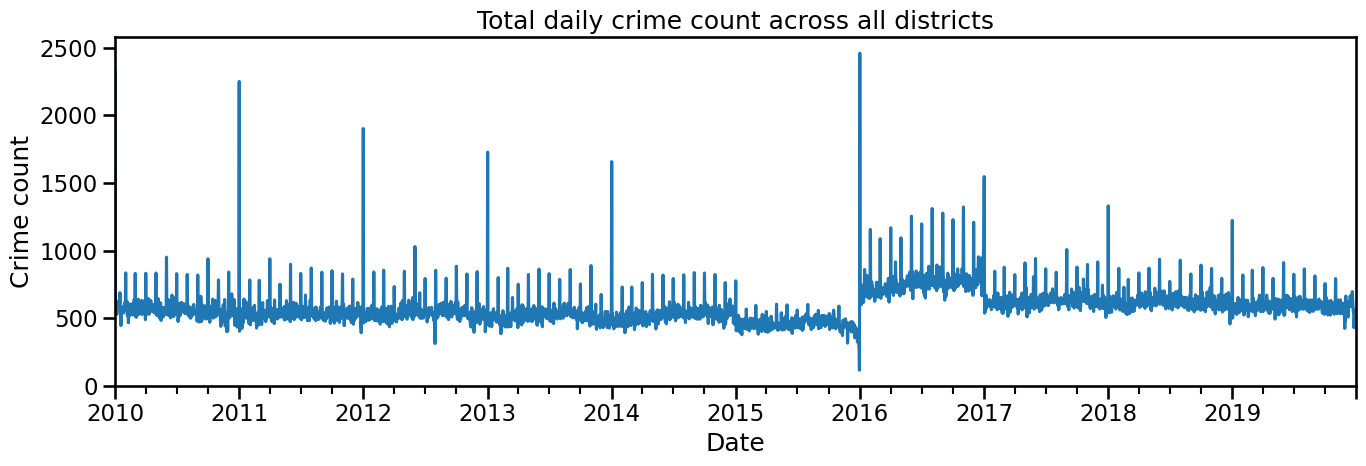

In [111]:
plt.figure(figsize=(14, 5))
panel_full.groupby("date")["crime_count"].sum().plot()
plt.title("Total daily crime count across all districts")
plt.xlabel("Date")
plt.ylabel("Crime count")
plt.tight_layout()
plt.show()

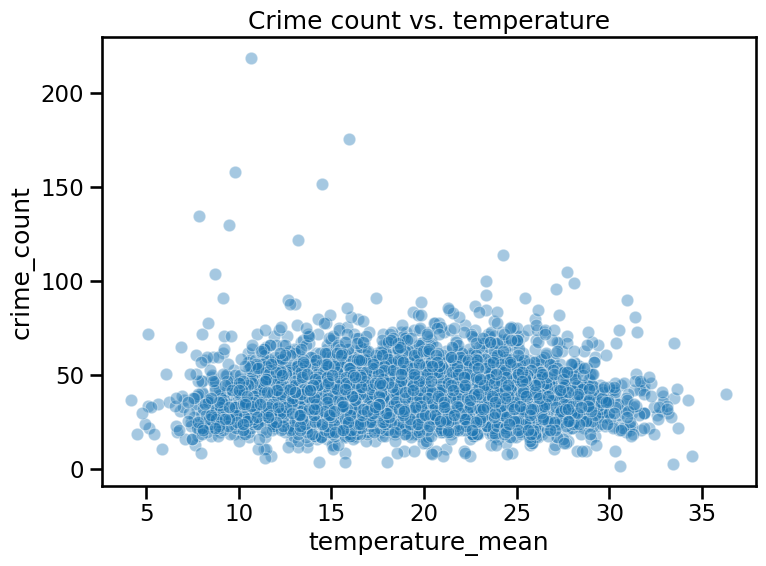

In [112]:
if "temperature_mean" in panel_full.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=panel_full.sample(min(len(panel_full), 5000), random_state=42),
                    x="temperature_mean", y="crime_count", alpha=0.4)
    plt.title("Crime count vs. temperature")
    plt.tight_layout()
    plt.show()

In [127]:
district_summary = (
    panel_full.groupby("district")
    .agg(
        avg_daily_crime=("crime_count", "mean"),
        total_crime=("crime_count", "sum"),
        days=("date", "nunique")
    )
    .reset_index()
)

if "Pop2010" in panel_full.columns:
    pop_by_district = panel_full.groupby("district")["Pop2010"].first().reset_index()
    district_summary = district_summary.merge(pop_by_district, on="district", how="left")
    district_summary["total_crime_per_1000"] = np.where(
        district_summary["Pop2010"] > 0,
        district_summary["total_crime"] / district_summary["Pop2010"] * 1000,
        np.nan
    )

district_summary.head()

,district,avg_daily_crime,total_crime,days,Pop2010,total_crime_per_1000
0,1,33.950986,123989,3652,245216.22,505.631316
1,2,33.862815,123667,3652,256691.84,481.772229
2,3,34.220975,124975,3652,257183.29,485.937481
3,4,35.721796,130456,3652,244117.22,534.399007
4,5,31.710296,115806,3652,252453.38,458.722319


District summary data:
    district  avg_daily_crime  total_crime  days    Pop2010  \
0          1        33.950986       123989  3652  245216.22   
1          2        33.862815       123667  3652  256691.84   
2          3        34.220975       124975  3652  257183.29   
3          4        35.721796       130456  3652  244117.22   
4          5        31.710296       115806  3652  252453.38   
5          6        36.643483       133822  3652  262111.74   
6          7        28.204819       103004  3652  256172.52   
7          8        53.634721       195874  3652  245838.53   
8          9        47.522453       173552  3652  248693.15   
9         10        43.963855       160556  3652  261297.85   
10        11        35.035597       127950  3652  250726.93   
11        12        30.789430       112443  3652  258715.95   
12        13        44.746166       163413  3652  247142.04   
13        14        51.950986       189725  3652  248489.10   
14        15        38.395126   

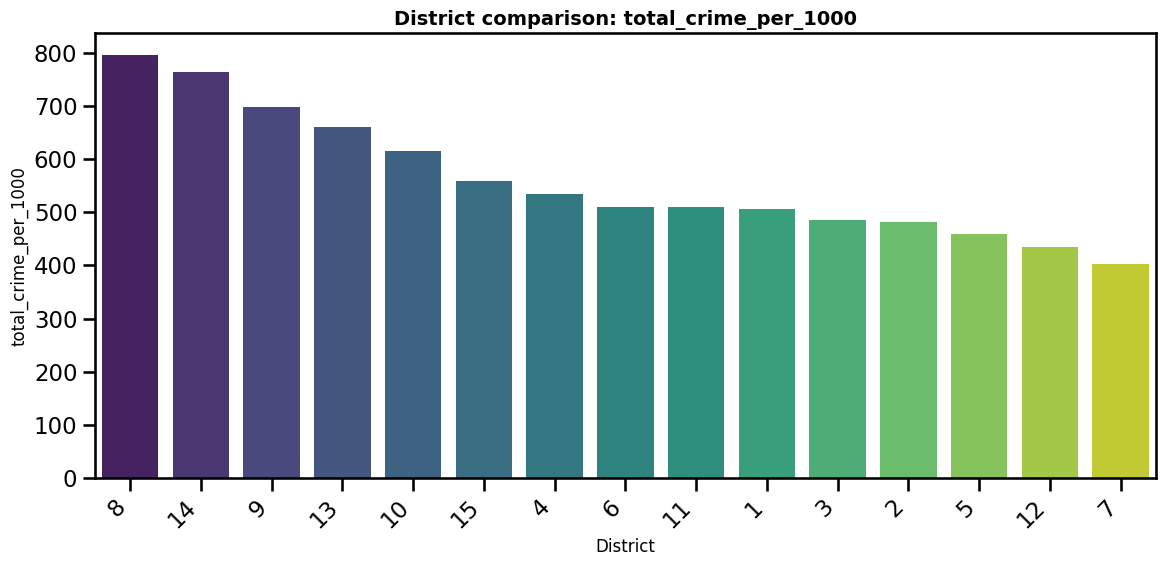

In [128]:
print("District summary data:")
print(district_summary)
print(f"\nDistrict column type: {district_summary['district'].dtype}")
print(f"Plot column: {plot_col}")

# Convert district to string for proper categorical plotting
plot_data = district_summary.copy()
plot_data["district"] = plot_data["district"].astype(str)
plot_data = plot_data.sort_values(plot_col, ascending=False)

print(f"\nTop 5 districts by {plot_col}:")
print(plot_data[["district", plot_col]].head())

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="district", y=plot_col, palette="viridis")
plt.title(f"District comparison: {plot_col}", fontsize=14, fontweight="bold")
plt.xlabel("District", fontsize=12)
plt.ylabel(plot_col, fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Correlation screen

This is only a first-pass screen. It does **not** prove causality.

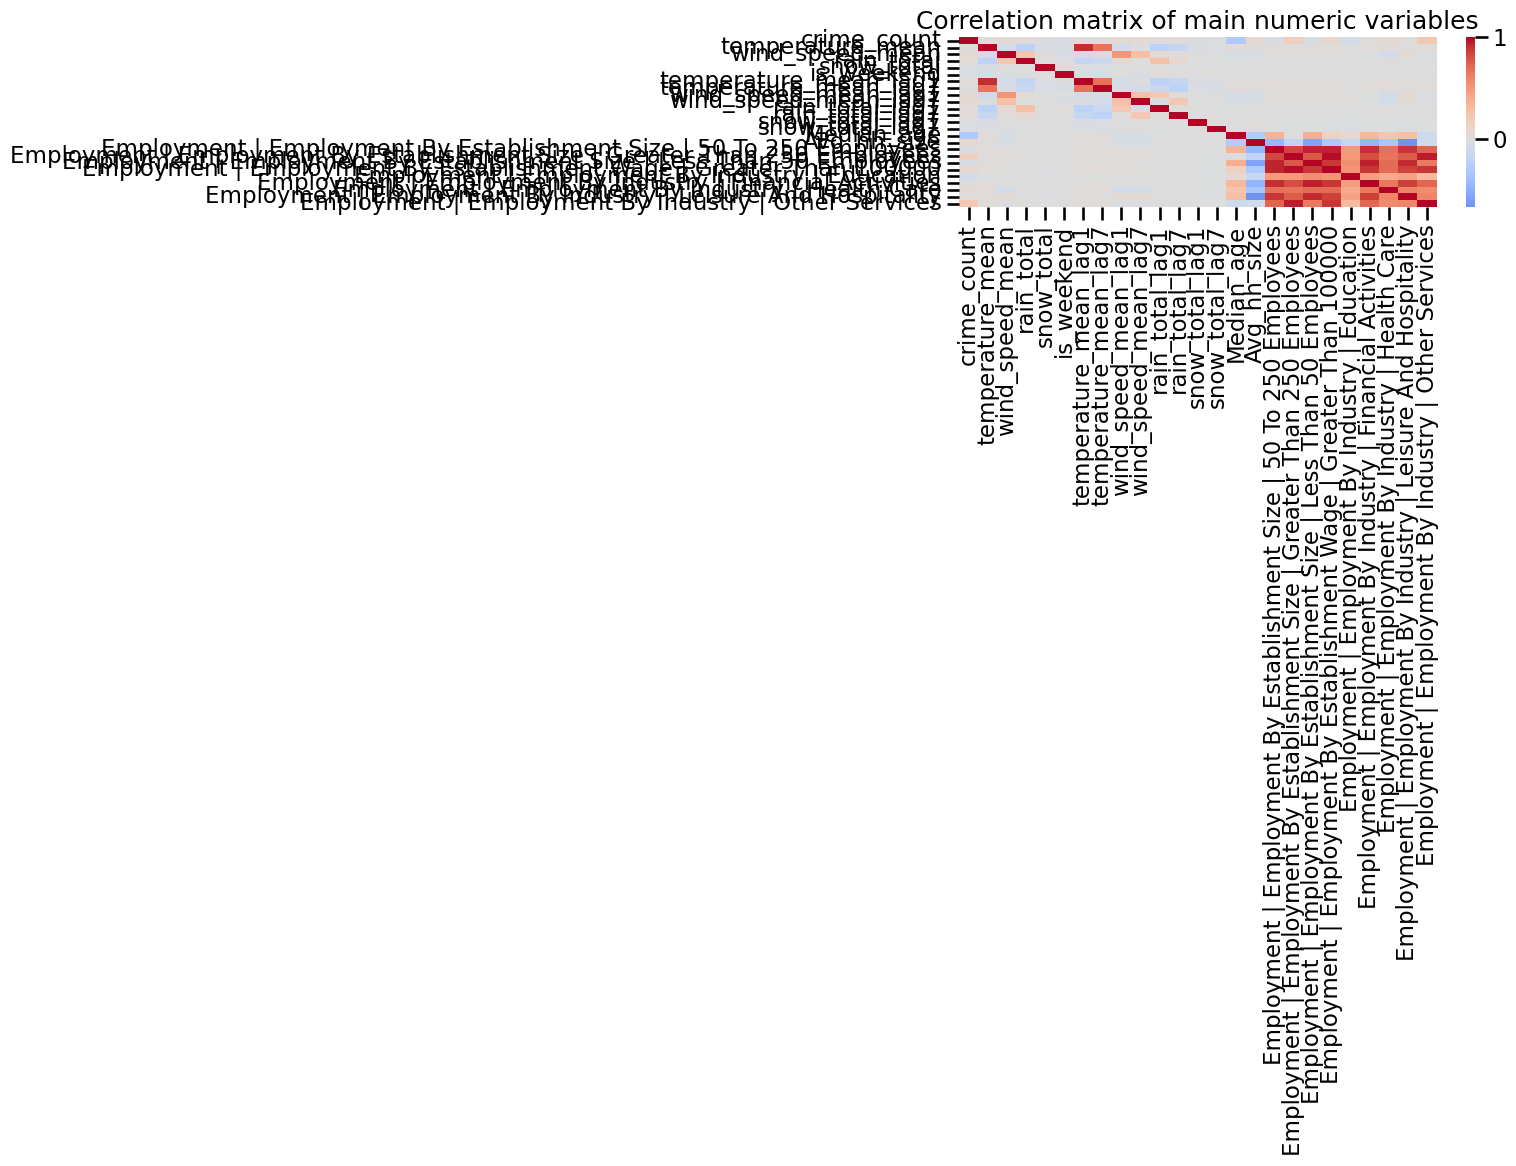

crime_count                                                                   1.000000
Employment | Employment By Industry | Other Services                          0.220440
Employment | Employment By Establishment Size | Greater Than 250 Employees    0.164107
Employment | Employment By Establishment Wage | Greater Than 100000           0.092381
Avg_hh_size                                                                   0.075758
wind_speed_mean_lag7                                                          0.068504
Employment | Employment By Industry | Health Care                             0.067952
wind_speed_mean_lag1                                                          0.053704
wind_speed_mean                                                               0.052035
rain_total                                                                    0.033802
rain_total_lag7                                                               0.033211
rain_total_lag1                            

In [29]:
candidate_numeric = [
    c for c in panel_full.columns
    if pd.api.types.is_numeric_dtype(panel_full[c]) and c not in ["district"]
]

# keep a reasonable subset for the heatmap
corr_cols = [c for c in candidate_numeric if panel_full[c].notna().mean() >= 0.6]
corr_cols = [c for c in corr_cols if c not in ["year", "month", "quarter", "day_of_week"]][:25]

corr = panel_full[corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix of main numeric variables")
plt.tight_layout()
plt.show()

corr["crime_count"].sort_values(ascending=False).head(15) if "crime_count" in corr.columns else None

## 10. Multivariable regression

### Why this model?
For count data like crime incidents, a count model is usually better than plain OLS.

We will fit:
1. OLS for easy interpretability
2. Poisson GLM for count outcomes

If you later want a stronger count model, switch to Negative Binomial.

In [30]:
# Candidate predictors
predictor_candidates = [
    "temperature_mean", "wind_speed_mean", "rain_total", "snow_total",
    "temperature_mean_lag1", "wind_speed_mean_lag1", "rain_total_lag1",
    "is_weekend"
]

predictor_candidates += [c for c in panel_full.columns if c.startswith("temperature_mean_lag7")]
predictor_candidates += [c for c in panel_full.columns if c.startswith("wind_speed_mean_lag7")]
predictor_candidates += [c for c in panel_full.columns if c.startswith("rain_total_lag7")]

# add socioeconomic vars
for c in available_socio:
    if c in panel_full.columns:
        predictor_candidates.append(c)

for c in ["renter_share", "owner_share", "sex_ratio_male"]:
    if c in panel_full.columns:
        predictor_candidates.append(c)

# add economic features
econ_feature_cols = [c for c in econ_wide.columns if c not in ["district", "econ_date"]]
predictor_candidates += [c for c in econ_feature_cols if c in panel_full.columns]

# add seasonal controls
predictor_candidates += ["year", "month", "day_of_week"]

predictor_candidates = [c for c in predictor_candidates if c in panel_full.columns]
predictor_candidates = list(dict.fromkeys(predictor_candidates))

print("Number of predictor candidates:", len(predictor_candidates))
predictor_candidates[:50]

Number of predictor candidates: 41


['temperature_mean',
 'wind_speed_mean',
 'rain_total',
 'snow_total',
 'temperature_mean_lag1',
 'wind_speed_mean_lag1',
 'rain_total_lag1',
 'is_weekend',
 'temperature_mean_lag7',
 'wind_speed_mean_lag7',
 'rain_total_lag7',
 'Pop2010',
 'Median_age',
 'Households',
 'Avg_hh_size',
 'Owner_occ',
 'Renter_occ',
 'White_pop',
 'Black_pop',
 'Hispanic_pop',
 'Asian_pop',
 'Male_pop',
 'Female_pop',
 'renter_share',
 'owner_share',
 'sex_ratio_male',
 'Employment | Employment By Establishment Size | 50 To 250 Employees',
 'Employment | Employment By Establishment Size | Greater Than 250 Employees',
 'Employment | Employment By Establishment Size | Less Than 50 Employees',
 'Employment | Employment By Establishment Wage | Greater Than 100000',
 'Employment | Employment By Industry | Education',
 'Employment | Employment By Industry | Financial Activities',
 'Employment | Employment By Industry | Health Care',
 'Employment | Employment By Industry | Leisure And Hospitality',
 'Employment 

In [31]:
# Keep columns with enough non-missing data
usable_predictors = [
    c for c in predictor_candidates
    if panel_full[c].notna().mean() >= 0.65 and panel_full[c].nunique(dropna=True) > 1
]

model_df = panel_full[["crime_count"] + usable_predictors].copy()

# Median imputation for a practical first pass
for c in usable_predictors:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")
    model_df[c] = model_df[c].fillna(model_df[c].median())

model_df = model_df.dropna(subset=["crime_count"]).copy()

print(model_df.shape)
model_df.head()

(54780, 29)


,crime_count,temperature_mean,wind_speed_mean,rain_total,snow_total,temperature_mean_lag1,wind_speed_mean_lag1,rain_total_lag1,is_weekend,temperature_mean_lag7,wind_speed_mean_lag7,rain_total_lag7,Median_age,Avg_hh_size,Employment | Employment By Establishment Size | 50 To 250 Employees,Employment | Employment By Establishment Size | Greater Than 250 Employees,Employment | Employment By Establishment Size | Less Than 50 Employees,Employment | Employment By Establishment Wage | Greater Than 100000,Employment | Employment By Industry | Education,Employment | Employment By Industry | Financial Activities,Employment | Employment By Industry | Health Care,Employment | Employment By Industry | Leisure And Hospitality,Employment | Employment By Industry | Other Services,Employment | Employment By Industry | Prof Sci Tech And Management,Employment | Employment By Industry | Transportation Warehousing And Utilities,Employment | Total Employment | Total All Industries,year,month,day_of_week
0,150,11.924667,6.198000,0.0,0.0,18.831818,7.275000,0.0,0,18.842857,7.273333,0.0,23.8,2.29,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,2010,1,4
1,29,16.689655,6.544828,0.0,0.0,11.924667,6.198000,0.0,1,18.842857,7.273333,0.0,23.8,2.29,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,2010,1,5
2,23,14.952174,7.860870,0.0,0.0,16.689655,6.544828,0.0,1,18.842857,7.273333,0.0,23.8,2.29,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,2010,1,6
3,20,13.895000,6.975000,0.0,0.0,14.952174,7.860870,0.0,0,18.842857,7.273333,0.0,23.8,2.29,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,2010,1,0
4,20,14.990000,5.475000,0.0,0.0,13.895000,6.975000,0.0,0,18.842857,7.273333,0.0,23.8,2.29,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,2010,1,1


In [32]:
# Remove highly collinear predictors
corr_abs = model_df[usable_predictors].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
regressors = [c for c in usable_predictors if c not in to_drop]

print("Dropped for high pairwise correlation:", to_drop)
print("Kept regressors:", len(regressors))
regressors[:40]

Dropped for high pairwise correlation: ['temperature_mean_lag1', 'Employment | Employment By Establishment Size | Less Than 50 Employees', 'Employment | Employment By Establishment Wage | Greater Than 100000', 'Employment | Employment By Industry | Financial Activities', 'Employment | Employment By Industry | Leisure And Hospitality', 'Employment | Employment By Industry | Other Services', 'Employment | Employment By Industry | Prof Sci Tech And Management', 'Employment | Total Employment | Total All Industries']
Kept regressors: 20


['temperature_mean',
 'wind_speed_mean',
 'rain_total',
 'snow_total',
 'wind_speed_mean_lag1',
 'rain_total_lag1',
 'is_weekend',
 'temperature_mean_lag7',
 'wind_speed_mean_lag7',
 'rain_total_lag7',
 'Median_age',
 'Avg_hh_size',
 'Employment | Employment By Establishment Size | 50 To 250 Employees',
 'Employment | Employment By Establishment Size | Greater Than 250 Employees',
 'Employment | Employment By Industry | Education',
 'Employment | Employment By Industry | Health Care',
 'Employment | Employment By Industry | Transportation Warehousing And Utilities',
 'year',
 'month',
 'day_of_week']

In [130]:
X = sm.add_constant(model_df[regressors])
y = model_df["crime_count"]

ols_model = sm.OLS(y, X).fit(cov_type="HC3")
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            crime_count   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     784.0
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:58:43   Log-Likelihood:            -2.1525e+05
No. Observations:               54780   AIC:                         4.305e+05
Df Residuals:                   54759   BIC:                         4.307e+05
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

In [34]:
poisson_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
).fit(cov_type="HC3")

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            crime_count   No. Observations:                54780
Model:                            GLM   Df Residuals:                    54759
Model Family:                 Poisson   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.4728e+05
Date:                Sat, 28 Mar 2026   Deviance:                   1.9673e+05
Time:                        20:38:52   Pearson chi2:                 2.14e+05
No. Iterations:                     5   Pseudo R-squ. (CS):             0.6431
Covariance Type:                  HC3                                         
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

## 11. Variance inflation factor (VIF)

This helps detect multi-collinearity among regressors.

In [35]:
vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df.head(20)

,variable,VIF
0,const,594882.587106
14,Employment | Employment By Establishment Size ...,10.702966
13,Employment | Employment By Establishment Size ...,9.213474
16,Employment | Employment By Industry | Health Care,3.979764
17,Employment | Employment By Industry | Transpor...,3.116762
7,is_weekend,2.679986
20,day_of_week,2.674092
11,Median_age,2.114484
8,temperature_mean_lag7,1.963572
1,temperature_mean,1.923638


## 12. Interaction effects

A useful question for your project is:

> Does temperature relate to crime differently in districts with different socio-economic profiles?

This cell adds one example interaction.

In [36]:
interaction_df = model_df.copy()

if "temperature_mean" in interaction_df.columns:
    socio_for_interaction = None
    for candidate in ["renter_share", "Pop2010", "Median_age", "Households"]:
        if candidate in interaction_df.columns:
            socio_for_interaction = candidate
            break

    if socio_for_interaction is not None:
        interaction_df["temp_x_socio"] = (
            interaction_df["temperature_mean"] * interaction_df[socio_for_interaction]
        )

        interaction_regressors = regressors.copy()
        if "temp_x_socio" not in interaction_regressors:
            interaction_regressors.append("temp_x_socio")

        X_int = sm.add_constant(interaction_df[interaction_regressors], has_constant="add")
        interaction_model = sm.OLS(interaction_df["crime_count"], X_int).fit(cov_type="HC3")

        print(f"Interaction variable: temperature_mean × {socio_for_interaction}")
        print(interaction_model.summary())
    else:
        print("No suitable socio-economic variable found for interaction.")
else:
    print("temperature_mean not available.")

Interaction variable: temperature_mean × Median_age
                            OLS Regression Results                            
Dep. Variable:            crime_count   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     748.0
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:38:59   Log-Likelihood:            -2.1524e+05
No. Observations:               54780   AIC:                         4.305e+05
Df Residuals:                   54758   BIC:                         4.307e+05
Df Model:                          21                                         
Covariance Type:                  HC3                                         
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------

## 13. Random forest feature importance

This complements regression by capturing non-linear relationships.

In [37]:
rf_features = regressors.copy()
rf_df = model_df[["crime_count"] + rf_features].copy()

X_rf = rf_df[rf_features]
y_rf = rf_df["crime_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print("Test MAE:", round(mean_absolute_error(y_test, pred), 4))
print("Test R^2:", round(r2_score(y_test, pred), 4))

importances = pd.Series(
    rf.named_steps["model"].feature_importances_,
    index=rf_features
).sort_values(ascending=False)

importances.head(20)

Test MAE: 6.4067
Test R^2: 0.5575


year                                                                              0.232968
Employment | Employment By Establishment Size | 50 To 250 Employees               0.184828
Employment | Employment By Industry | Health Care                                 0.165542
Avg_hh_size                                                                       0.072044
Employment | Employment By Industry | Transportation Warehousing And Utilities    0.064807
Median_age                                                                        0.046239
temperature_mean                                                                  0.042048
Employment | Employment By Industry | Education                                   0.032168
temperature_mean_lag7                                                             0.024981
Employment | Employment By Establishment Size | Greater Than 250 Employees        0.024179
wind_speed_mean_lag7                                                              0.022837

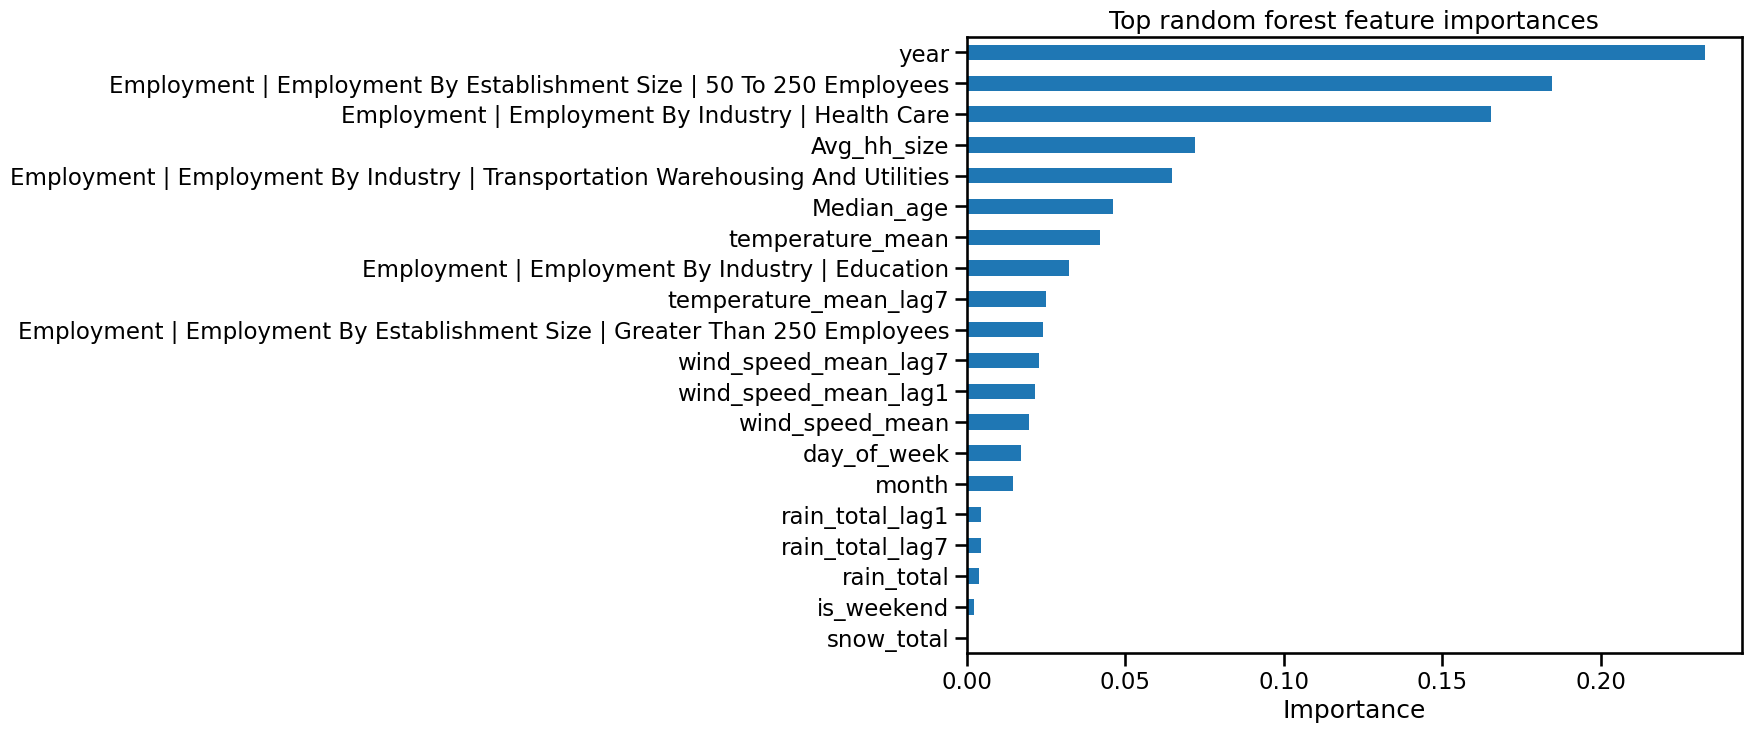

In [38]:
plt.figure(figsize=(10, 8))
importances.head(20).sort_values().plot(kind="barh")
plt.title("Top random forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 14. Fixed-effects style regression (district and month controls)

This is closer to a panel-data setup and is often more convincing than a simple pooled model.

In [131]:
# fe_df = panel_full.copy()

# fe_predictors = [c for c in ["temperature_mean", "wind_speed_mean", "rain_total", "snow_total", "is_weekend"] if c in fe_df.columns]
# if "crime_rate_per_1000" in fe_df.columns:
#     target_var = "crime_rate_per_1000"
# else:
#     target_var = "crime_count"

# keep_cols = [target_var, "district", "month", "year"] + fe_predictors
# fe_df = fe_df[keep_cols].dropna().copy()
# for col in ["district", "month", "year"]:
#     if col in fe_df.columns:
#         fe_df[col] = fe_df[col].astype("int64")
# formula = target_var + " ~ " + " + ".join(fe_predictors) + " + C(district) + C(month) + C(year)"
# fe_model = smf.ols(formula=formula, data=fe_df).fit(cov_type="HC3")
# print(fe_model.summary())
fe_df = panel_full.copy()

# Select predictors that actually exist
fe_predictors = [
    c for c in ["temperature_mean", "wind_speed_mean", "rain_total", "snow_total", "is_weekend"]
    if c in fe_df.columns
]

# Target variable
target_var = "crime_rate_per_1000" if "crime_rate_per_1000" in fe_df.columns else "crime_count"

# Keep only needed columns
keep_cols = [target_var, "district", "month", "year"] + fe_predictors
fe_df = fe_df[keep_cols].copy()

# Convert everything to numeric safely
for col in ["district", "month", "year"] + fe_predictors + [target_var]:
    if col in fe_df.columns:
        fe_df[col] = pd.to_numeric(fe_df[col], errors="coerce")

# Drop missing values once (more efficient)
fe_df = fe_df.dropna().copy()

# Convert categorical identifiers to int (required for statsmodels)
for col in ["district", "month", "year"]:
    fe_df[col] = fe_df[col].astype("int64")

# Build formula
predictor_part = " + ".join(fe_predictors) if fe_predictors else "1"
formula = f"{target_var} ~ {predictor_part} + C(district) + C(month) + C(year)"

# Fit model with robust standard errors
fe_model = smf.ols(formula=formula, data=fe_df).fit(cov_type="HC3")

print(fe_model.summary())

                             OLS Regression Results                            
Dep. Variable:     crime_rate_per_1000   R-squared:                       0.472
Model:                             OLS   Adj. R-squared:                  0.471
Method:                  Least Squares   F-statistic:                     1088.
Date:                 Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                         21:58:54   Log-Likelihood:                 97903.
No. Observations:                54780   AIC:                        -1.957e+05
Df Residuals:                    54740   BIC:                        -1.954e+05
Df Model:                           39                                         
Covariance Type:                   HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.1362

In [133]:

# Extract key coefficients from all three models
print("=" * 80)
print("RESULTS SUMMARY: KEY FINDINGS ACROSS ALL MODELS")
print("=" * 80)

# Get coefficients and p-values from OLS
ols_coef = ols_model.params
ols_pval = ols_model.pvalues

# Get coefficients and p-values from Poisson
poisson_coef = poisson_model.params
poisson_pval = poisson_model.pvalues

# Get coefficients and p-values from Fixed-Effects
fe_coef = fe_model.params
fe_pval = fe_model.pvalues

# Create comparison table for key variables
key_vars = []
for var in regressors:
    if var in ols_coef.index and var in poisson_coef.index and var in fe_coef.index:
        key_vars.append(var)

comp_data = []
for var in key_vars[:25]:  # Top 25 variables
    ols_sig = "***" if ols_pval[var] < 0.001 else "**" if ols_pval[var] < 0.01 else "*" if ols_pval[var] < 0.05 else ""
    poisson_sig = "***" if poisson_pval[var] < 0.001 else "**" if poisson_pval[var] < 0.01 else "*" if poisson_pval[var] < 0.05 else ""
    fe_sig = "***" if fe_pval[var] < 0.001 else "**" if fe_pval[var] < 0.01 else "*" if fe_pval[var] < 0.05 else ""
    
    comp_data.append({
        "Variable": var,
        "OLS Coef": f"{ols_coef[var]:.4f}{ols_sig}",
        "Poisson Coef": f"{poisson_coef[var]:.4f}{poisson_sig}",
        "FE Coef": f"{fe_coef[var]:.4f}{fe_sig}",
        "OLS p-value": f"{ols_pval[var]:.4f}",
        "Poisson p-value": f"{poisson_pval[var]:.4f}",
        "FE p-value": f"{fe_pval[var]:.4f}"
    })

comp_df = pd.DataFrame(comp_data)

print("\nKEY COEFFICIENTS ACROSS ALL MODELS")
print("(*** p<0.001, ** p<0.01, * p<0.05)")
print(comp_df.to_string(index=False))

# Identify significant variables in each model
print("\n" + "=" * 80)
print("SIGNIFICANT VARIABLES BY MODEL (p < 0.05)")
print("=" * 80)

ols_sig = ols_pval[ols_pval < 0.05].drop('const', errors='ignore').index.tolist()
poisson_sig = poisson_pval[poisson_pval < 0.05].drop('const', errors='ignore').index.tolist()
fe_sig = fe_pval[fe_pval < 0.05].drop('const', errors='ignore').index.tolist()

print(f"\nOLS Model ({len(ols_sig)} significant variables):")
for var in ols_sig[:15]:
    print(f"  • {var}: coef={ols_coef[var]:.4f}, p={ols_pval[var]:.4f}")

print(f"\nPoisson GLM ({len(poisson_sig)} significant variables):")
for var in poisson_sig[:15]:
    print(f"  • {var}: coef={poisson_coef[var]:.4f}, p={poisson_pval[var]:.4f}")

print(f"\nFixed-Effects Model ({len(fe_sig)} significant variables):")
for var in fe_sig[:15]:
    print(f"  • {var}: coef={fe_coef[var]:.4f}, p={fe_pval[var]:.4f}")

# Find consistent findings (significant in multiple models)
consistent = set(ols_sig) & set(poisson_sig) & set(fe_sig)
print(f"\n" + "=" * 80)
print(f"CONSISTENT ACROSS ALL 3 MODELS ({len(consistent)} variables):")
print("=" * 80)
for var in consistent:
    print(f"\n✓ {var.upper()}")
    print(f"  OLS:      coef={ols_coef[var]:+.6f}  p={ols_pval[var]:.4f}")
    print(f"  Poisson:  coef={poisson_coef[var]:+.6f}  p={poisson_pval[var]:.4f}")
    print(f"  FE:       coef={fe_coef[var]:+.6f}  p={fe_pval[var]:.4f}")
    
    # Interpret effect
    if var in ["temperature_mean", "wind_speed_mean", "rain_total", "snow_total"]:
        direction = "INCREASES" if ols_coef[var] > 0 else "DECREASES"
        magnitude = abs(ols_coef[var])
        print(f"  ➜ Interpretation: +1 unit {direction} crime by ~{magnitude:.3f} (avg effect)")
    elif var in ["renter_share", "Pop2010", "Median_age"]:
        direction = "HIGHER" if ols_coef[var] > 0 else "LOWER"
        print(f"  ➜ Interpretation: {direction} values associated with more crime")

print("\n" + "=" * 80)
print(f"MODEL FIT COMPARISON")
print("=" * 80)
print(f"OLS R-squared:        {ols_model.rsquared:.4f}")
print(f"OLS Adj R-squared:    {ols_model.rsquared_adj:.4f}")
print(f"\nPoisson GLM LL:       {poisson_model.llf:.2f}")
print(f"Poisson AIC:          {poisson_model.aic:.2f}")
print(f"\nFE Model R-squared:   {fe_model.rsquared:.4f}")
print(f"FE Model Adj R-sq:    {fe_model.rsquared_adj:.4f}")


RESULTS SUMMARY: KEY FINDINGS ACROSS ALL MODELS

KEY COEFFICIENTS ACROSS ALL MODELS
(*** p<0.001, ** p<0.01, * p<0.05)
        Variable    OLS Coef Poisson Coef    FE Coef OLS p-value Poisson p-value FE p-value
temperature_mean   0.1315***    0.0034***  0.0004***      0.0000          0.0000     0.0000
 wind_speed_mean      0.0172       0.0001  -0.0002**      0.4731          0.8588     0.0020
      rain_total   0.0440***    0.0011***  0.0001***      0.0000          0.0000     0.0009
      snow_total -32.4060***   -1.2525***   -0.0580*      0.0004          0.0000     0.0156
      is_weekend  -2.5932***   -0.0668*** -0.0032***      0.0000          0.0000     0.0000

SIGNIFICANT VARIABLES BY MODEL (p < 0.05)

OLS Model (17 significant variables):
  • temperature_mean: coef=0.1315, p=0.0000
  • rain_total: coef=0.0440, p=0.0000
  • snow_total: coef=-32.4060, p=0.0004
  • rain_total_lag1: coef=0.0438, p=0.0000
  • is_weekend: coef=-2.5932, p=0.0000
  • temperature_mean_lag7: coef=-0.0370, p=

## 15. Summary: Key findings across all models

In [134]:

print("=" * 80)
print("ECONOMIC INDICATORS ANALYSIS")
print("=" * 80)

# Check what economic features were selected
print("\n✓ ECONOMIC FEATURES INCLUDED IN MODELS:")
print(f"Total economic features selected: {len(SELECTED_ECON_FEATURES)}")
for i, feat in enumerate(SELECTED_ECON_FEATURES, 1):
    print(f"  {i}. {feat}")

# Check coverage of economic data
print("\n\n⚠ ECONOMIC DATA COVERAGE ANALYSIS:")
econ_coverage = (
    econ_work.groupby("feature_name")
    .agg({
        "district": "nunique",
        "econ_date": "nunique", 
        "value_num": ["count", "mean", "std"]
    })
    .round(2)
)
econ_coverage.columns = ["Districts", "Time_Periods", "Observations", "Mean_Value", "Std_Dev"]
econ_coverage = econ_coverage.sort_values("Time_Periods", ascending=False)
print(econ_coverage.head(20))

# Check if wage data exists
print("\n\n🔍 SEARCH FOR WAGE-RELATED INDICATORS:")
wage_indicators = econ_work[econ_work["feature_name"].str.contains("wage|wage|compensation|salary|earnings", case=False, na=False)]["feature_name"].unique()
if len(wage_indicators) > 0:
    print(f"✓ Found {len(wage_indicators)} wage-related indicators:")
    for w in wage_indicators:
        print(f"  • {w}")
        coverage_info = econ_work[econ_work["feature_name"] == w].groupby("feature_name").agg({"district": "nunique", "econ_date": "nunique"})
        print(f"    Coverage: {coverage_info['district'].values[0]} districts × {coverage_info['econ_date'].values[0]} time periods")
else:
    print("✗ No wage-related indicators found in economic data")

# Check employment indicators
print("\n🔍 SEARCH FOR EMPLOYMENT-RELATED INDICATORS:")
emp_indicators = econ_work[econ_work["feature_name"].str.contains("employ|job|labor|workforce", case=False, na=False)]["feature_name"].unique()
if len(emp_indicators) > 0:
    print(f"✓ Found {len(emp_indicators)} employment-related indicators:")
    for e in emp_indicators[:10]:
        print(f"  • {e}")
else:
    print("✗ No employment-related indicators found")

# Temporal coverage 
print("\n\n📅 TEMPORAL COVERAGE OF ECONOMIC DATA:")
print(f"Crime-weather data time range: {panel_full['date'].min()} to {panel_full['date'].max()}")
print(f"Economic data time range: {econ_work['econ_date'].min()} to {econ_work['econ_date'].max()}")
print(f"\n⚠️  Gap: Economic data ends {(panel_full['date'].max() - econ_work['econ_date'].max()).days} days before crime data")
print(f"   This means ~{(panel_full['date'].max() - econ_work['econ_date'].max()).days / 365:.1f} years of crime-weather observations are missing economic context")

# Show which features made it into regression
print("\n\n✓ FEATURES ACTUALLY USED IN REGRESSION MODELS:")
econ_in_regressors = [r for r in regressors if "Employment" in r or "Establishments" in r or any(f in r for f in SELECTED_ECON_FEATURES)]
print(f"Economic variables in final OLS model: {len([r for r in regressors if any(f in r for f in SELECTED_ECON_FEATURES)])}")
for r in regressors:
    if any(f in r for f in SELECTED_ECON_FEATURES):
        sig = "***" if ols_pval[r] < 0.001 else "**" if ols_pval[r] < 0.01 else "*" if ols_pval[r] < 0.05 else ""
        print(f"  • {r}: coef={ols_coef[r]:+.6f} {sig}")


ECONOMIC INDICATORS ANALYSIS

✓ ECONOMIC FEATURES INCLUDED IN MODELS:
Total economic features selected: 12
  1. Employment | Total Employment | Total All Industries
  2. Employment | Employment By Establishment Wage | Greater Than 100000
  3. Employment | Employment By Establishment Size | Greater Than 250 Employees
  4. Employment | Employment By Industry | Other Services
  5. Employment | Employment By Establishment Size | Less Than 50 Employees
  6. Employment | Employment By Industry | Education
  7. Employment | Employment By Establishment Size | 50 To 250 Employees
  8. Employment | Employment By Industry | Prof Sci Tech And Management
  9. Employment | Employment By Industry | Health Care
  10. Employment | Employment By Industry | Transportation Warehousing And Utilities
  11. Employment | Employment By Industry | Leisure And Hospitality
  12. Employment | Employment By Industry | Financial Activities


⚠ ECONOMIC DATA COVERAGE ANALYSIS:
                                        

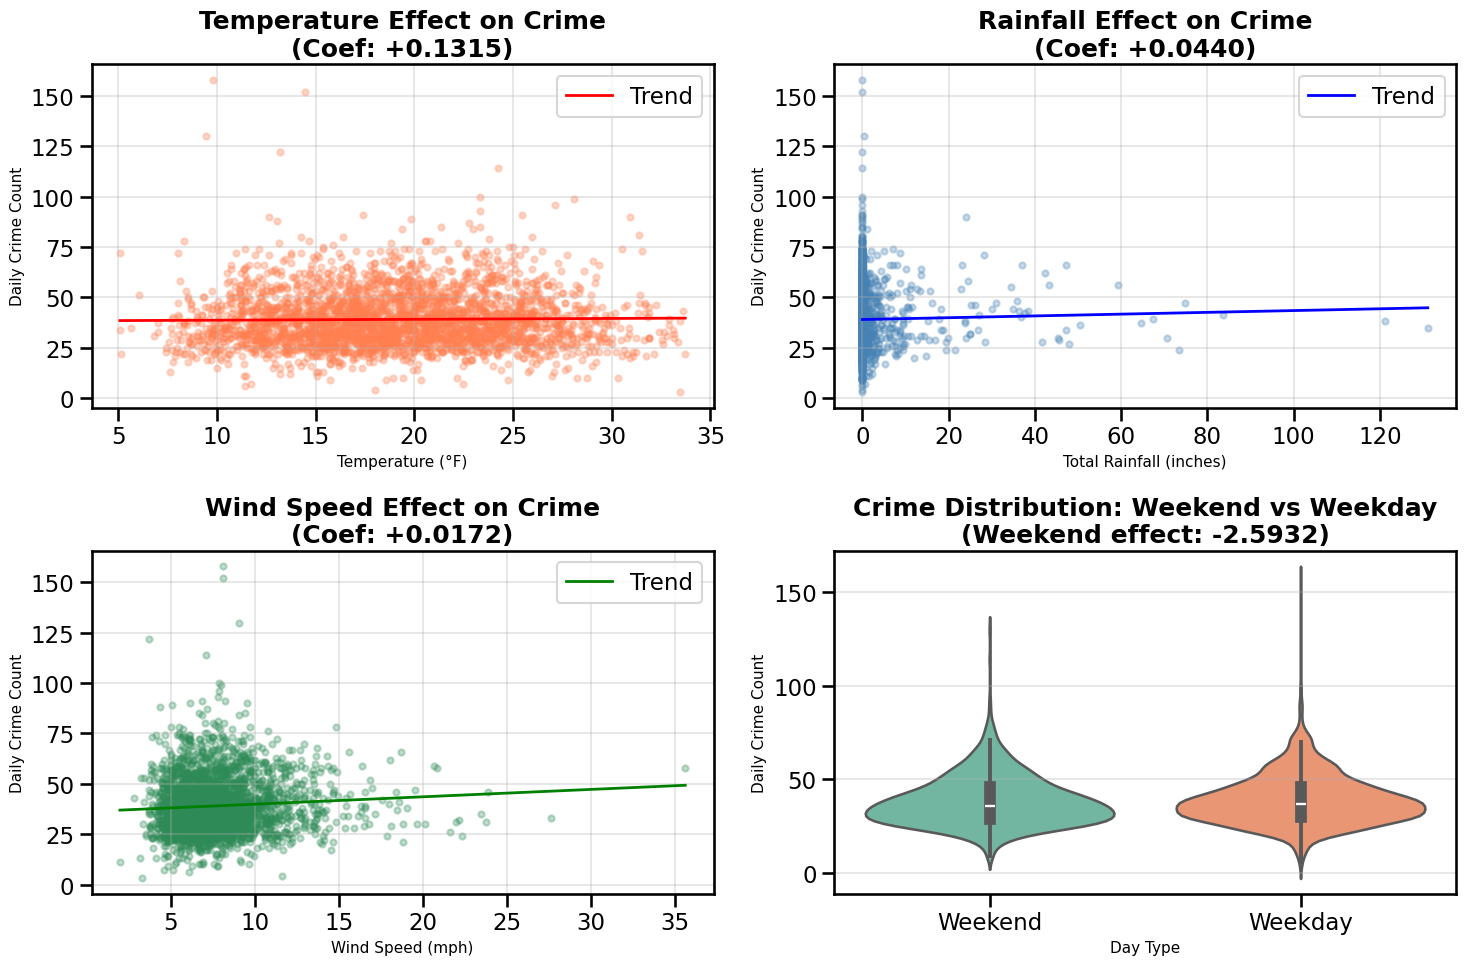

✓ Weather effects visualization saved


In [135]:

# Create comprehensive weather effect visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Temperature vs Crime
panel_sample = panel_full.sample(min(3000, len(panel_full)), random_state=42)
axes[0, 0].scatter(panel_sample["temperature_mean"], panel_sample["crime_count"], 
                   alpha=0.3, s=20, color="coral")
# Add trend line
z = np.polyfit(panel_sample["temperature_mean"].dropna(), 
               panel_sample.loc[panel_sample["temperature_mean"].notna(), "crime_count"], 1)
p = np.poly1d(z)
temp_range = np.linspace(panel_sample["temperature_mean"].min(), 
                         panel_sample["temperature_mean"].max(), 100)
axes[0, 0].plot(temp_range, p(temp_range), "r-", linewidth=2, label="Trend")
axes[0, 0].set_xlabel("Temperature (°F)", fontsize=11)
axes[0, 0].set_ylabel("Daily Crime Count", fontsize=11)
axes[0, 0].set_title(f"Temperature Effect on Crime\n(Coef: {ols_coef.get('temperature_mean', 0):+.4f})", fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Rain vs Crime
axes[0, 1].scatter(panel_sample["rain_total"], panel_sample["crime_count"], 
                   alpha=0.3, s=20, color="steelblue")
z_rain = np.polyfit(panel_sample["rain_total"].dropna(), 
                    panel_sample.loc[panel_sample["rain_total"].notna(), "crime_count"], 1)
p_rain = np.poly1d(z_rain)
rain_range = np.linspace(0, panel_sample["rain_total"].max(), 100)
axes[0, 1].plot(rain_range, p_rain(rain_range), "b-", linewidth=2, label="Trend")
axes[0, 1].set_xlabel("Total Rainfall (inches)", fontsize=11)
axes[0, 1].set_ylabel("Daily Crime Count", fontsize=11)
axes[0, 1].set_title(f"Rainfall Effect on Crime\n(Coef: {ols_coef.get('rain_total', 0):+.4f})", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Wind Speed vs Crime
axes[1, 0].scatter(panel_sample["wind_speed_mean"], panel_sample["crime_count"], 
                   alpha=0.3, s=20, color="seagreen")
z_wind = np.polyfit(panel_sample["wind_speed_mean"].dropna(), 
                    panel_sample.loc[panel_sample["wind_speed_mean"].notna(), "crime_count"], 1)
p_wind = np.poly1d(z_wind)
wind_range = np.linspace(panel_sample["wind_speed_mean"].min(), 
                         panel_sample["wind_speed_mean"].max(), 100)
axes[1, 0].plot(wind_range, p_wind(wind_range), "g-", linewidth=2, label="Trend")
axes[1, 0].set_xlabel("Wind Speed (mph)", fontsize=11)
axes[1, 0].set_ylabel("Daily Crime Count", fontsize=11)
axes[1, 0].set_title(f"Wind Speed Effect on Crime\n(Coef: {ols_coef.get('wind_speed_mean', 0):+.4f})", fontweight="bold")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Weekend vs Weekday comparison
panel_sample["day_type"] = panel_sample["is_weekend"].map({1: "Weekend", 0: "Weekday"})
sns.violinplot(data=panel_sample, x="day_type", y="crime_count", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_xlabel("Day Type", fontsize=11)
axes[1, 1].set_ylabel("Daily Crime Count", fontsize=11)
axes[1, 1].set_title(f"Crime Distribution: Weekend vs Weekday\n(Weekend effect: {ols_coef.get('is_weekend', 0):+.4f})", fontweight="bold")
axes[1, 1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("01_weather_effects_on_crime.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Weather effects visualization saved")


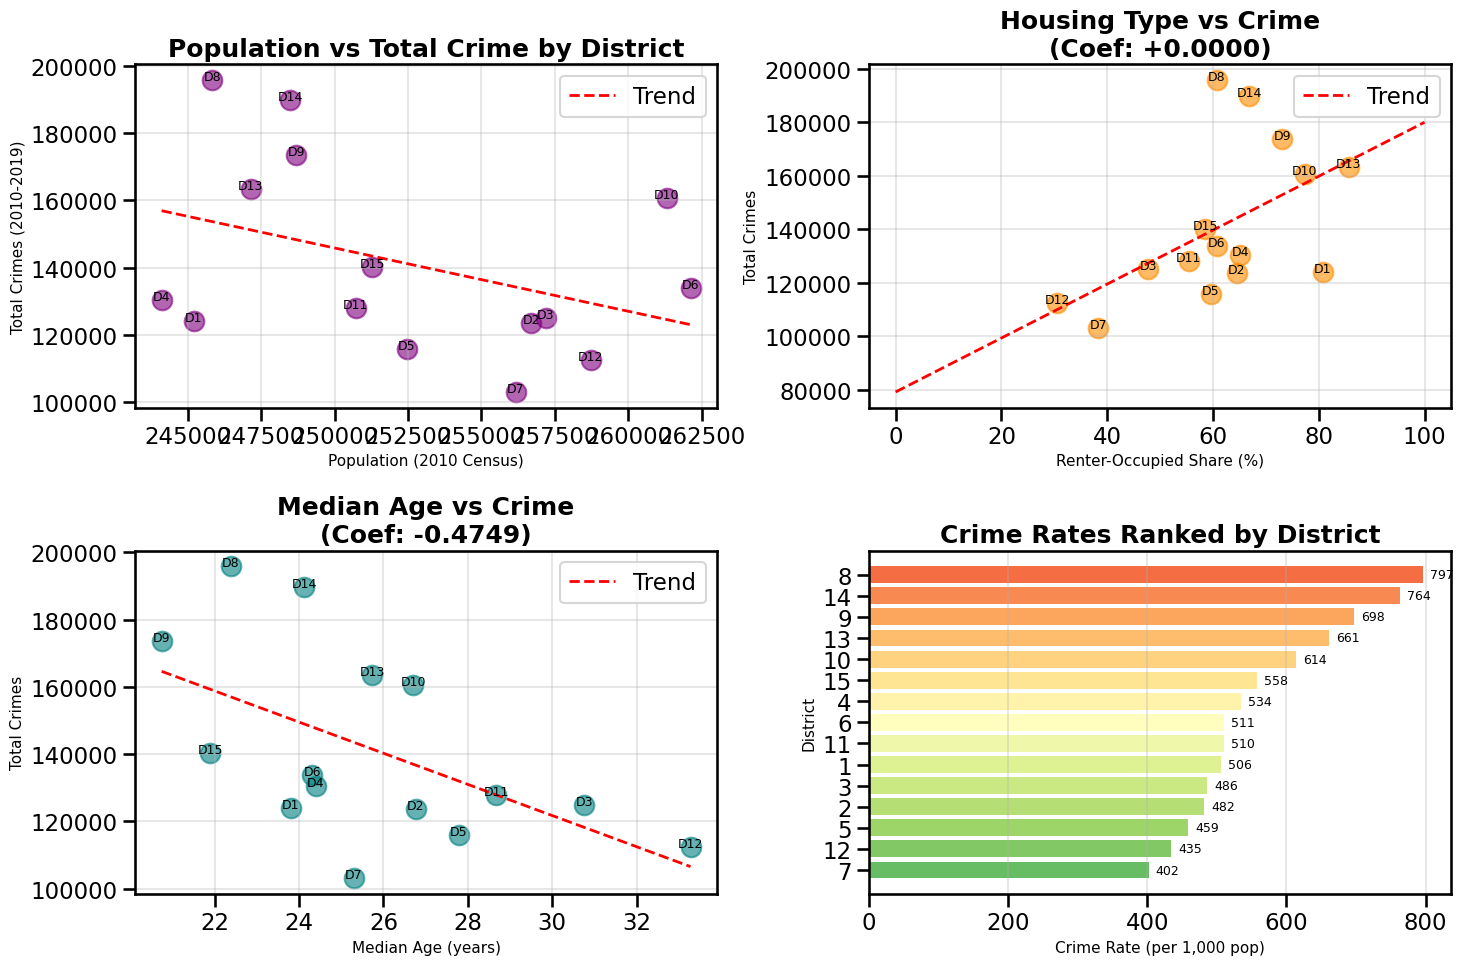

✓ Socioeconomic effects visualization saved


In [136]:

# Create socioeconomic effect visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Population vs Crime (district-level aggregation)
district_data = panel_full.groupby("district").agg({
    "Pop2010": "first",
    "crime_count": "sum"
}).reset_index()

axes[0, 0].scatter(district_data["Pop2010"], district_data["crime_count"], 
                   s=200, alpha=0.6, color="purple")
for idx, row in district_data.iterrows():
    axes[0, 0].annotate(f"D{int(row['district'])}", 
                        (row["Pop2010"], row["crime_count"]),
                        fontsize=9, ha="center")
z_pop = np.polyfit(district_data["Pop2010"], district_data["crime_count"], 1)
p_pop = np.poly1d(z_pop)
pop_range = np.linspace(district_data["Pop2010"].min(), district_data["Pop2010"].max(), 100)
axes[0, 0].plot(pop_range, p_pop(pop_range), "r--", linewidth=2, label="Trend")
axes[0, 0].set_xlabel("Population (2010 Census)", fontsize=11)
axes[0, 0].set_ylabel("Total Crimes (2010-2019)", fontsize=11)
axes[0, 0].set_title("Population vs Total Crime by District", fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Renter Share vs Crime (district-level)
district_data2 = panel_full.dropna(subset=["renter_share"]).groupby("district").agg({
    "renter_share": "first",
    "crime_count": "sum"
}).reset_index()

axes[0, 1].scatter(district_data2["renter_share"]*100, district_data2["crime_count"], 
                   s=200, alpha=0.6, color="darkorange")
for idx, row in district_data2.iterrows():
    axes[0, 1].annotate(f"D{int(row['district'])}", 
                        (row["renter_share"]*100, row["crime_count"]),
                        fontsize=9, ha="center")
z_renter = np.polyfit(district_data2["renter_share"], district_data2["crime_count"], 1)
p_renter = np.poly1d(z_renter)
renter_range = np.linspace(0, 1, 100)
axes[0, 1].plot(renter_range*100, p_renter(renter_range), "r--", linewidth=2, label="Trend")
axes[0, 1].set_xlabel("Renter-Occupied Share (%)", fontsize=11)
axes[0, 1].set_ylabel("Total Crimes", fontsize=11)
axes[0, 1].set_title(f"Housing Type vs Crime\n(Coef: {ols_coef.get('renter_share', 0):+.4f})", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Median Age vs Crime (district-level)
if "Median_age" in panel_full.columns:
    district_data3 = panel_full.dropna(subset=["Median_age"]).groupby("district").agg({
        "Median_age": "first",
        "crime_count": "sum"
    }).reset_index()
    
    axes[1, 0].scatter(district_data3["Median_age"], district_data3["crime_count"], 
                       s=200, alpha=0.6, color="teal")
    for idx, row in district_data3.iterrows():
        axes[1, 0].annotate(f"D{int(row['district'])}", 
                            (row["Median_age"], row["crime_count"]),
                            fontsize=9, ha="center")
    z_age = np.polyfit(district_data3["Median_age"], district_data3["crime_count"], 1)
    p_age = np.poly1d(z_age)
    age_range = np.linspace(district_data3["Median_age"].min(), district_data3["Median_age"].max(), 100)
    axes[1, 0].plot(age_range, p_age(age_range), "r--", linewidth=2, label="Trend")
    axes[1, 0].set_xlabel("Median Age (years)", fontsize=11)
    axes[1, 0].set_ylabel("Total Crimes", fontsize=11)
    axes[1, 0].set_title(f"Median Age vs Crime\n(Coef: {ols_coef.get('Median_age', 0):+.4f})", fontweight="bold")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

# 4. Crime rate rankings by district
district_ranking = district_summary.sort_values("total_crime_per_1000", ascending=True)
colors_rank = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(district_ranking)))
axes[1, 1].barh(district_ranking["district"].astype(str), 
                district_ranking["total_crime_per_1000"], color=colors_rank)
axes[1, 1].set_xlabel("Crime Rate (per 1,000 pop)", fontsize=11)
axes[1, 1].set_ylabel("District", fontsize=11)
axes[1, 1].set_title("Crime Rates Ranked by District", fontweight="bold")
axes[1, 1].grid(alpha=0.3, axis="x")

# Add values on bars
for i, (idx, row) in enumerate(district_ranking.iterrows()):
    axes[1, 1].text(row["total_crime_per_1000"] + 10, i, f"{row['total_crime_per_1000']:.0f}", 
                    va="center", fontsize=9)

plt.tight_layout()
plt.savefig("02_socioeconomic_effects_on_crime.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Socioeconomic effects visualization saved")


KeyError: 'rain_total_lag1'

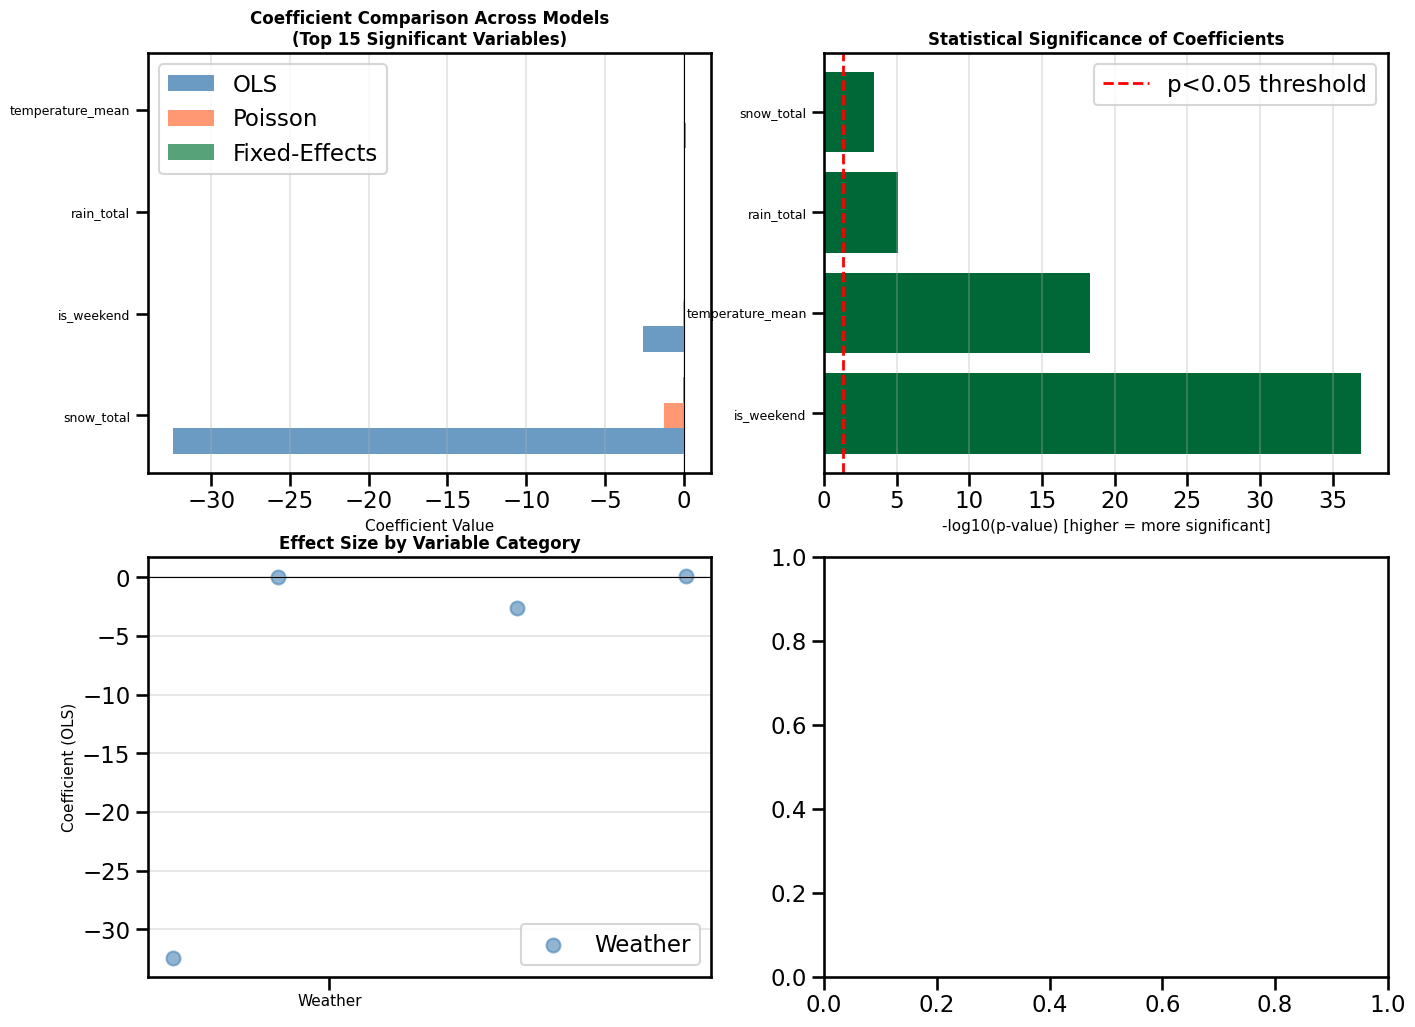

In [140]:

# Extract significant coefficients for visualization
sig_vars = ols_sig[:20]  # Top 20 significant variables

sig_coef_data = []
for var in sig_vars:
    # Only include variables that exist in all models
    if var in ols_coef.index and var in poisson_coef.index and var in fe_coef.index:
        sig_coef_data.append({
            "Variable": var,
            "OLS_Coef": ols_coef[var],
            "OLS_Pval": ols_pval[var],
            "Poisson_Coef": poisson_coef[var],
            "FE_Coef": fe_coef[var],
            "Significant": ols_pval[var] < 0.05
        })

sig_df = pd.DataFrame(sig_coef_data)

# Create comprehensive coefficient visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Coefficient magnitudes by model (top 15)
top_15 = sig_df.head(15).sort_values("OLS_Coef")
x_pos = np.arange(len(top_15))
width = 0.25

axes[0, 0].barh(x_pos - width, top_15["OLS_Coef"], width, label="OLS", alpha=0.8, color="steelblue")
axes[0, 0].barh(x_pos, top_15["Poisson_Coef"], width, label="Poisson", alpha=0.8, color="coral")
axes[0, 0].barh(x_pos + width, top_15["FE_Coef"], width, label="Fixed-Effects", alpha=0.8, color="seagreen")
axes[0, 0].set_yticks(x_pos)
axes[0, 0].set_yticklabels(top_15["Variable"], fontsize=9)
axes[0, 0].set_xlabel("Coefficient Value", fontsize=11)
axes[0, 0].set_title("Coefficient Comparison Across Models\n(Top 15 Significant Variables)", fontweight="bold", fontsize=12)
axes[0, 0].legend(loc="best")
axes[0, 0].axvline(x=0, color="black", linestyle="-", linewidth=0.8)
axes[0, 0].grid(alpha=0.3, axis="x")

# 2. P-values for significance (smaller = more significant)
top_vars_pval = sig_df.head(15).sort_values("OLS_Pval")
colors_pval = plt.cm.RdYlGn_r(np.linspace(top_vars_pval["OLS_Pval"].max(), 
                                          top_vars_pval["OLS_Pval"].min(), len(top_vars_pval)))
axes[0, 1].barh(range(len(top_vars_pval)), -np.log10(top_vars_pval["OLS_Pval"]), color=colors_pval)
axes[0, 1].set_yticks(range(len(top_vars_pval)))
axes[0, 1].set_yticklabels(top_vars_pval["Variable"], fontsize=9)
axes[0, 1].set_xlabel("-log10(p-value) [higher = more significant]", fontsize=11)
axes[0, 1].set_title("Statistical Significance of Coefficients", fontweight="bold", fontsize=12)
axes[0, 1].axvline(x=-np.log10(0.05), color="red", linestyle="--", linewidth=2, label="p<0.05 threshold")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis="x")

# 3. Weather vs Socioeconomic vs Other - categorized effect sizes
var_types = []
for var in sig_vars:
    if any(w in var for w in ["temperature", "wind", "rain", "snow"]):
        var_types.append("Weather")
    elif any(s in var for s in ["Pop", "Median_age", "Households", "share", "ratio"]):
        var_types.append("Socioeconomic")
    elif any(e in var for e in ["Employment", "Establishments", "Wage"]):
        var_types.append("Economic")
    else:
        var_types.append("Other")

sig_df["Type"] = var_types[:len(sig_df)]

# Group by type and plot
type_effects = sig_df.groupby("Type")["OLS_Coef"].apply(list)
type_positions = []
type_labels = []
type_colors = {"Weather": "steelblue", "Socioeconomic": "coral", "Economic": "seagreen", "Other": "gray"}

for i, (type_name, effects) in enumerate(type_effects.items()):
    y_pos = np.random.normal(i, 0.04, size=len(effects))
    axes[1, 0].scatter(y_pos, effects, s=100, alpha=0.6, color=type_colors.get(type_name, "gray"), 
                       label=type_name)

axes[1, 0].set_xticks(range(len(type_effects)))
axes[1, 0].set_xticklabels(type_effects.index, fontsize=11)
axes[1, 0].set_ylabel("Coefficient (OLS)", fontsize=11)
axes[1, 0].set_title("Effect Size by Variable Category", fontweight="bold", fontsize=12)
axes[1, 0].axhline(y=0, color="black", linestyle="-", linewidth=0.8)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis="y")

# 4. Model agreement: which models agree?
agreement_data = []
for var in sig_vars[:12]:
    ols_sig_flag = 1 if ols_pval[var] < 0.05 else 0
    poisson_sig_flag = 1 if poisson_pval[var] < 0.05 else 0
    fe_sig_flag = 1 if fe_pval[var] < 0.05 else 0
    agreement = ols_sig_flag + poisson_sig_flag + fe_sig_flag
    
    agreement_data.append({
        "Variable": var,
        "Models_Agree": agreement,
        "OLS_p": ols_pval[var],
        "Poisson_p": poisson_pval[var],
        "FE_p": fe_pval[var]
    })

agreement_df = pd.DataFrame(agreement_data).sort_values("Models_Agree", ascending=True)
colors_agree = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 4))
bar_colors = [colors_agree[int(x)-1] for x in agreement_df["Models_Agree"]]

axes[1, 1].barh(range(len(agreement_df)), agreement_df["Models_Agree"], color=bar_colors)
axes[1, 1].set_yticks(range(len(agreement_df)))
axes[1, 1].set_yticklabels(agreement_df["Variable"], fontsize=9)
axes[1, 1].set_xlabel("# of Models with p<0.05", fontsize=11)
axes[1, 1].set_xlim(0, 3.5)
axes[1, 1].set_xticks([1, 2, 3])
axes[1, 1].set_title("Model Agreement: Consistency of Findings", fontweight="bold", fontsize=12)
axes[1, 1].grid(alpha=0.3, axis="x")

# Add labels
for i, (idx, row) in enumerate(agreement_df.iterrows()):
    axes[1, 1].text(row["Models_Agree"] + 0.05, i, 
                    f"{int(row['Models_Agree'])}/3", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("03_coefficient_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Coefficient comparison visualization saved")


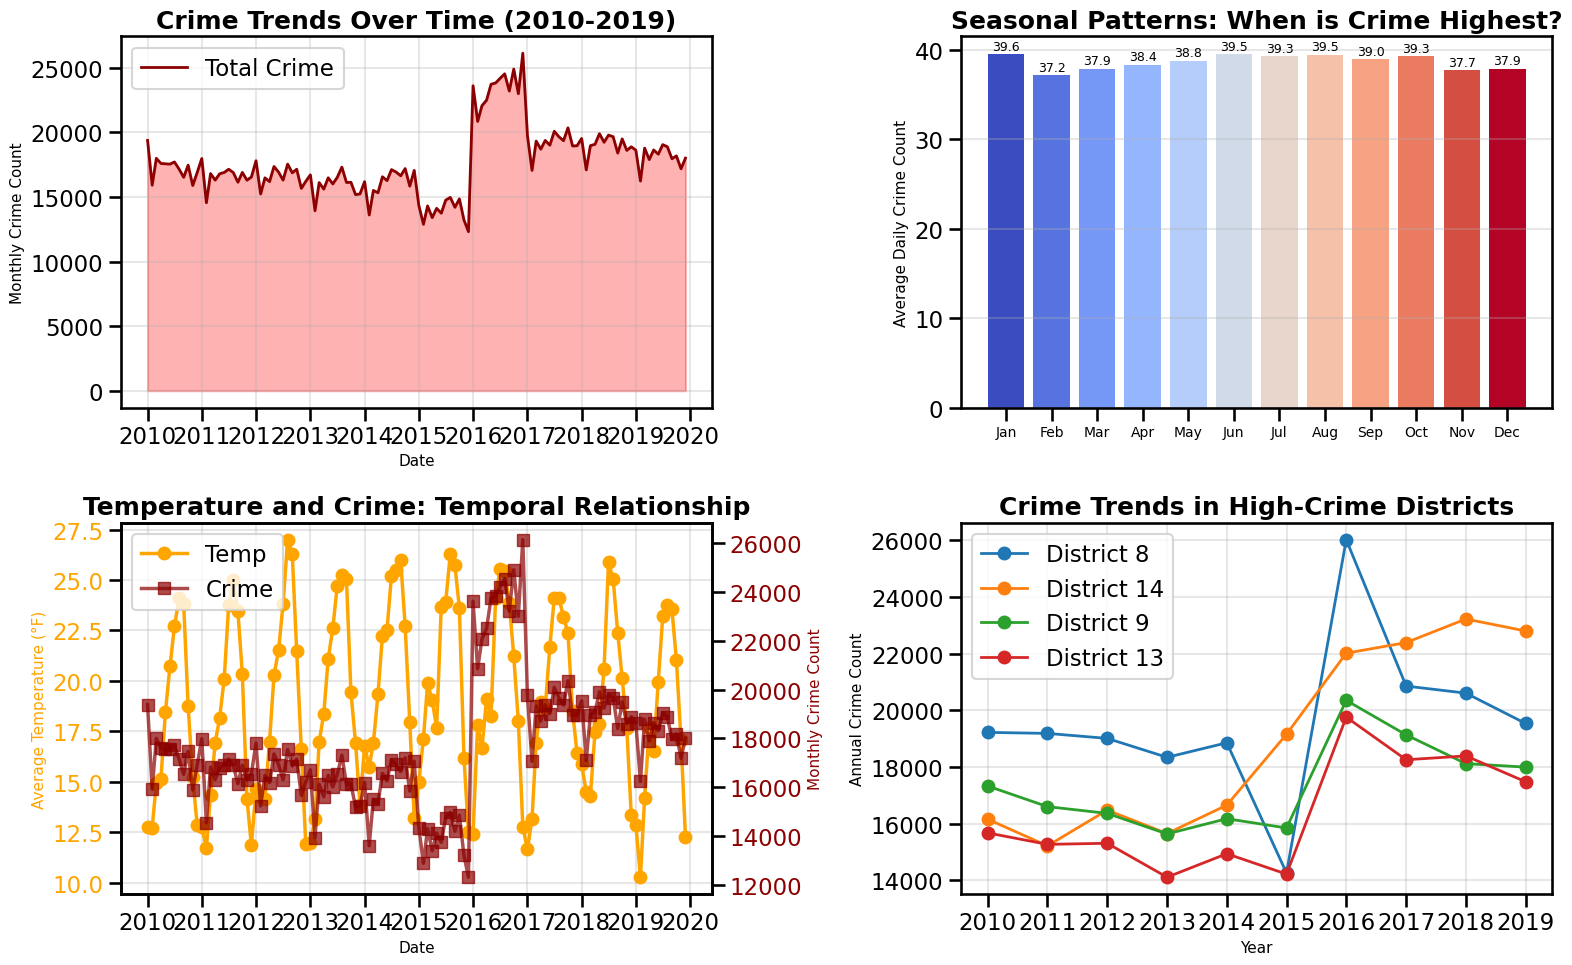

✓ Temporal patterns visualization saved


In [138]:

# Create temporal trend analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Crime trends over time
monthly_crime = panel_full.groupby(panel_full["date"].dt.to_period("M"))["crime_count"].sum()
monthly_crime.index = monthly_crime.index.to_timestamp()
axes[0, 0].plot(monthly_crime.index, monthly_crime.values, linewidth=2, color="darkred", label="Total Crime")
axes[0, 0].fill_between(monthly_crime.index, monthly_crime.values, alpha=0.3, color="red")
axes[0, 0].set_xlabel("Date", fontsize=11)
axes[0, 0].set_ylabel("Monthly Crime Count", fontsize=11)
axes[0, 0].set_title("Crime Trends Over Time (2010-2019)", fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Seasonal patterns
panel_full["month_name"] = pd.to_datetime(panel_full["date"]).dt.strftime("%B")
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]
seasonal_crime = panel_full.groupby("month_name")["crime_count"].mean().reindex(month_order)
axes[0, 1].bar(range(12), seasonal_crime.values, color=plt.cm.coolwarm(np.linspace(0, 1, 12)))
axes[0, 1].set_xticks(range(12))
axes[0, 1].set_xticklabels([m[:3] for m in month_order], fontsize=10)
axes[0, 1].set_ylabel("Average Daily Crime Count", fontsize=11)
axes[0, 1].set_title("Seasonal Patterns: When is Crime Highest?", fontweight="bold")
axes[0, 1].grid(alpha=0.3, axis="y")

# Add values on bars
for i, v in enumerate(seasonal_crime.values):
    axes[0, 1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=9)

# 3. Weather seasonality
monthly_temp = panel_full.groupby(panel_full["date"].dt.to_period("M"))["temperature_mean"].mean()
monthly_temp.index = monthly_temp.index.to_timestamp()
ax3a = axes[1, 0]
ax3b = ax3a.twinx()

ax3a.plot(monthly_temp.index, monthly_temp.values, linewidth=2.5, color="orange", label="Temp", marker="o")
monthly_crime2 = panel_full.groupby(panel_full["date"].dt.to_period("M"))["crime_count"].sum()
monthly_crime2.index = monthly_crime2.index.to_timestamp()
ax3b.plot(monthly_crime2.index, monthly_crime2.values, linewidth=2.5, color="darkred", label="Crime", marker="s", alpha=0.7)

ax3a.set_xlabel("Date", fontsize=11)
ax3a.set_ylabel("Average Temperature (°F)", fontsize=11, color="orange")
ax3b.set_ylabel("Monthly Crime Count", fontsize=11, color="darkred")
ax3a.tick_params(axis="y", labelcolor="orange")
ax3b.tick_params(axis="y", labelcolor="darkred")
axes[1, 0].set_title("Temperature and Crime: Temporal Relationship", fontweight="bold")
ax3a.grid(alpha=0.3)

# Add legends
lines1, labels1 = ax3a.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3a.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# 4. District variation over time
district_monthly = panel_full.groupby(["district", panel_full["date"].dt.to_period("Y")])["crime_count"].sum().reset_index()
district_monthly["date"] = district_monthly["date"].dt.to_timestamp()

top_districts = panel_full.groupby("district")["crime_count"].sum().nlargest(4).index
for dist in top_districts:
    dist_data = district_monthly[district_monthly["district"] == dist]
    axes[1, 1].plot(dist_data["date"], dist_data["crime_count"], marker="o", label=f"District {int(dist)}", linewidth=2)

axes[1, 1].set_xlabel("Year", fontsize=11)
axes[1, 1].set_ylabel("Annual Crime Count", fontsize=11)
axes[1, 1].set_title("Crime Trends in High-Crime Districts", fontweight="bold")
axes[1, 1].legend(loc="best")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("04_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Temporal patterns visualization saved")


In [141]:

print("=" * 100)
print("COMPREHENSIVE DISTRICT PROFILES: DEMOGRAPHICS, HOUSING, AND CRIME")
print("=" * 100)

# First, check what demographic columns exist in socio_clean
print("\n📊 AVAILABLE DEMOGRAPHIC VARIABLES IN SOCIOECONOMIC DATA:")
print("Columns in socio_clean:")
for col in socio_clean.columns:
    print(f"  • {col}")

# Build comprehensive district profile
district_profile = panel_full.groupby("district").agg({
    "crime_count": ["sum", "mean"],
    "Pop2010": "first",
    "renter_share": "first",
    "owner_share": "first",
    "Median_age": "first",
    "Households": "first",
    "date": "nunique"  # Number of days tracked
}).reset_index()

district_profile.columns = ["District", "Total_Crime", "Daily_Crime_Avg", "Population_2010", 
                            "Renter_Share_%", "Owner_Share_%", "Median_Age", "Households", "Days_Tracked"]

# Add ethnic/demographic breakdowns if available
demographic_cols = [c for c in socio_clean.columns if c not in ["district", "Pop2010", "renter_share", "owner_share", "Median_age", "Households", "Avg_hh_size"]]

if len(demographic_cols) > 0:
    for col in demographic_cols[:10]:  # Top demographic columns
        if col in panel_full.columns:
            pop_data = panel_full.groupby("district")[col].first().reset_index()
            pop_data.columns = ["District", col]
            district_profile = district_profile.merge(pop_data, on="District", how="left")

# Convert percentages and calculate criminality rates
district_profile["Renter_Share_%"] = (district_profile["Renter_Share_%"] * 100).round(1)
district_profile["Owner_Share_%"] = (district_profile["Owner_Share_%"] * 100).round(1)
district_profile["Crime_Rate_Per_1000_Pop"] = (district_profile["Total_Crime"] / district_profile["Population_2010"] * 1000).round(1)

# Sort by crime rate
district_profile_sorted = district_profile.sort_values("Crime_Rate_Per_1000_Pop", ascending=False)

print("\n" + "=" * 100)
print("DISTRICT PROFILE SUMMARY (sorted by crime rate)")
print("=" * 100)
print(district_profile_sorted[["District", "Population_2010", "Renter_Share_%", "Owner_Share_%", 
                               "Median_Age", "Households", "Crime_Rate_Per_1000_Pop"]].to_string(index=False))

# Calculate correlations for key relationships
print("\n\n" + "=" * 100)
print("CORRELATIONS: How Demographics Relate to Crime")
print("=" * 100)

correlation_analysis = district_profile[["Renter_Share_%", "Owner_Share_%", "Median_Age", 
                                         "Population_2010", "Households", "Crime_Rate_Per_1000_Pop"]].corr()
print("\nCorrelation with Crime Rate:")
print(correlation_analysis["Crime_Rate_Per_1000_Pop"].sort_values(ascending=False))

# Find top and bottom crime districts for comparison
print("\n\n" + "=" * 100)
print("DISTRICT COMPARISON: Highest vs Lowest Crime Areas")
print("=" * 100)

highest_crime = district_profile_sorted.iloc[0]
lowest_crime = district_profile_sorted.iloc[-1]

comparison_data = pd.DataFrame({
    "Metric": ["Crime Rate (per 1000)", "Population", "Renter Share %", "Owner Share %", 
               "Median Age", "Households", "Total Crimes"],
    "Highest_Crime_District": [
        f"{highest_crime['Crime_Rate_Per_1000_Pop']:.1f}",
        f"{int(highest_crime['Population_2010']):,}",
        f"{highest_crime['Renter_Share_%']:.1f}%",
        f"{highest_crime['Owner_Share_%']:.1f}%",
        f"{highest_crime['Median_Age']:.1f}",
        f"{int(highest_crime['Households']):,}",
        f"{int(highest_crime['Total_Crime']):,}"
    ],
    "Lowest_Crime_District": [
        f"{lowest_crime['Crime_Rate_Per_1000_Pop']:.1f}",
        f"{int(lowest_crime['Population_2010']):,}",
        f"{lowest_crime['Renter_Share_%']:.1f}%",
        f"{lowest_crime['Owner_Share_%']:.1f}%",
        f"{lowest_crime['Median_Age']:.1f}",
        f"{int(lowest_crime['Households']):,}",
        f"{int(lowest_crime['Total_Crime']):,}"
    ]
})

print(f"\n📍 HIGHEST CRIME: District {int(highest_crime['District'])}")
print("vs")
print(f"📍 LOWEST CRIME: District {int(lowest_crime['District'])}")
print("\n" + comparison_data.to_string(index=False))

# Key differences
print("\n\nKEY DIFFERENCES:")
renter_diff = highest_crime['Renter_Share_%'] - lowest_crime['Renter_Share_%']
age_diff = highest_crime['Median_Age'] - lowest_crime['Median_Age']
pop_diff = highest_crime['Population_2010'] - lowest_crime['Population_2010']

print(f"  • Renter share: {renter_diff:+.1f}% (Highest has {'MORE' if renter_diff > 0 else 'FEWER'} renters)")
print(f"  • Median age: {age_diff:+.1f} years (Highest is {'YOUNGER' if age_diff < 0 else 'OLDER'})")
print(f"  • Population: {pop_diff:+,} people")



COMPREHENSIVE DISTRICT PROFILES: DEMOGRAPHICS, HOUSING, AND CRIME

📊 AVAILABLE DEMOGRAPHIC VARIABLES IN SOCIOECONOMIC DATA:
Columns in socio_clean:
  • district
  • Council District
  • Pop2010
  • White_pop
  • Black_pop
  • Ameri_es_pop
  • Asian_pop
  • Hawn_pi_pop
  • Hispanic_pop
  • Other_pop
  • Multi_pop
  • Male_pop
  • Female_pop
  • Age_under5Ê
  • Age_5_9
  • Age_10_14
  • Age_15_19
  • Age_20_24
  • Age_25_34
  • Age_35_44
  • Age_45_54
  • Age_55_64
  • Age_65_74
  • Age_75_84
  • Age_85_up
  • Median_age
  • Med_age_male
  • Med_age_female
  • Households
  • Avg_hh_size
  • HouseholdsHsehld_1_m
  • Hsehld_1_f
  • Marhh_chd
  • Marhh_no_c
  • Mhh_child
  • Fhh_child
  • Families
  • Avg_family_size
  • Housing_units
  • Vacant
  • Owner_occ
  • Renter_occ

DISTRICT PROFILE SUMMARY (sorted by crime rate)
 District  Population_2010  Renter_Share_%  Owner_Share_%  Median_Age  Households  Crime_Rate_Per_1000_Pop
        8        245838.53            60.7           39.3       

In [148]:

# Create detailed demographic profile with ethnic composition
print("\n" + "=" * 100)
print("DISTRICT ETHNIC/NATIONALITY COMPOSITION BY DISTRICT")
print("=" * 100)

ethnic_cols = ["White_pop", "Black_pop", "Asian_pop", "Hispanic_pop", "Other_pop"]
demo_by_district = socio_clean[["district", "Pop2010"] + ethnic_cols].copy()

# Calculate percentages
for col in ethnic_cols:
    demo_by_district[col + "_pct"] = (demo_by_district[col] / demo_by_district["Pop2010"] * 100).round(1)

# Merge with crime data
crime_by_district = panel_full.groupby("district").agg({
    "crime_count": ["sum", "mean"],
    "renter_share": "first"
}).reset_index()
crime_by_district.columns = ["district", "Total_Crime", "Avg_Daily_Crime", "Renter_Share"]
crime_by_district["Crime_Rate_Per_1000"] = (crime_by_district["Total_Crime"] / 
                                             demo_by_district["Pop2010"].values * 1000).round(1)
crime_by_district["Renter_Share_Pct"] = (crime_by_district["Renter_Share"] * 100).round(1)

# Combine everything
full_profile = demo_by_district.merge(crime_by_district, on="district")

# Create sorted display
display_cols = ["district", "Pop2010", "White_pop_pct", "Black_pop_pct", "Asian_pop_pct", 
                "Hispanic_pop_pct", "Other_pop_pct", "Renter_Share_Pct", "Crime_Rate_Per_1000"]
full_profile_display = full_profile[display_cols].sort_values("Crime_Rate_Per_1000", ascending=False)
full_profile_display.columns = ["District", "Population", "White_%", "Black_%", "Asian_%", 
                                "Hispanic_%", "Other_%", "Renters_%", "Crime_Rate"]

print("\n" + full_profile_display.to_string(index=False))

print("\n\n" + "=" * 100)
print("DEMOGRAPHIC INSIGHTS BY CRIME LEVEL")
print("=" * 100)

# Categorize districts by crime level
median_crime = full_profile["Crime_Rate_Per_1000"].median()
high_crime = full_profile[full_profile["Crime_Rate_Per_1000"] > median_crime]
low_crime = full_profile[full_profile["Crime_Rate_Per_1000"] <= median_crime]

print(f"\n🔴 HIGH CRIME DISTRICTS (Crime Rate > {median_crime:.1f} per 1000): {len(high_crime)} districts")
print(f"   Average demographics:")
print(f"   • White: {high_crime['White_pop_pct'].mean():.1f}%")
print(f"   • Black: {high_crime['Black_pop_pct'].mean():.1f}%")
print(f"   • Asian: {high_crime['Asian_pop_pct'].mean():.1f}%")
print(f"   • Hispanic: {high_crime['Hispanic_pop_pct'].mean():.1f}%")
print(f"   • Other: {high_crime['Other_pop_pct'].mean():.1f}%")
print(f"   • Renters: {(high_crime['Renter_Share'] * 100).mean():.1f}%")

print(f"\n🟢 LOW CRIME DISTRICTS (Crime Rate ≤ {median_crime:.1f} per 1000): {len(low_crime)} districts")
print(f"   Average demographics:")
print(f"   • White: {low_crime['White_pop_pct'].mean():.1f}%")
print(f"   • Black: {low_crime['Black_pop_pct'].mean():.1f}%")
print(f"   • Asian: {low_crime['Asian_pop_pct'].mean():.1f}%")
print(f"   • Hispanic: {low_crime['Hispanic_pop_pct'].mean():.1f}%")
print(f"   • Other: {low_crime['Other_pop_pct'].mean():.1f}%")
print(f"   • Renters: {(low_crime['Renter_Share'] * 100).mean():.1f}%")

# Statistical tests - correlation analysis
print("\n\n" + "=" * 100)
print("STATISTICAL RELATIONSHIPS: Demographics, Housing, and Crime")
print("=" * 100)

# Calculate correlations with crime rate
demo_crime_corr = pd.DataFrame({
    "Variable": ["White Population %", "Black Population %", "Asian Population %", 
                 "Hispanic Population %", "Other Population %", "Renter Share %"],
    "Correlation_with_Crime": [
        full_profile["White_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        full_profile["Black_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        full_profile["Asian_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        full_profile["Hispanic_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        full_profile["Other_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        (full_profile["Renter_Share"] * 100).corr(full_profile["Crime_Rate_Per_1000"])
    ]
})

demo_crime_corr["Abs_Correlation"] = demo_crime_corr["Correlation_with_Crime"].abs()
demo_crime_corr = demo_crime_corr.sort_values("Abs_Correlation", ascending=False)

print("\nCorrelation Strength (closer to 1.0 = stronger relationship):")
print(demo_crime_corr[["Variable", "Correlation_with_Crime"]].to_string(index=False))




DISTRICT ETHNIC/NATIONALITY COMPOSITION BY DISTRICT

 District  Population  White_%  Black_%  Asian_%  Hispanic_%  Other_%  Renters_%  Crime_Rate
       14   248489.10     45.7      6.3     12.7        67.4     29.9       66.9       771.7
        8   245838.53     21.2     41.7      1.4        54.2     30.7       60.7       763.1
        9   248693.15     32.0     15.8      2.5        77.9     44.4       73.1       674.8
       10   261297.85     26.2     25.7     16.5        48.6     26.1       77.3       657.7
       13   247142.04     45.9      3.7     17.7        53.8     26.7       85.6       637.9
       15   251283.55     43.0     13.1      6.5        62.2     30.7       58.6       563.8
        6   262111.74     47.2      3.8      9.5        70.1     34.0       60.8       538.5
       11   250726.93     69.4      5.4     12.0        18.8      7.5       55.4       506.8
        1   245216.22     37.1      3.2     17.7        70.5     35.9       80.7       505.6
        4   2441

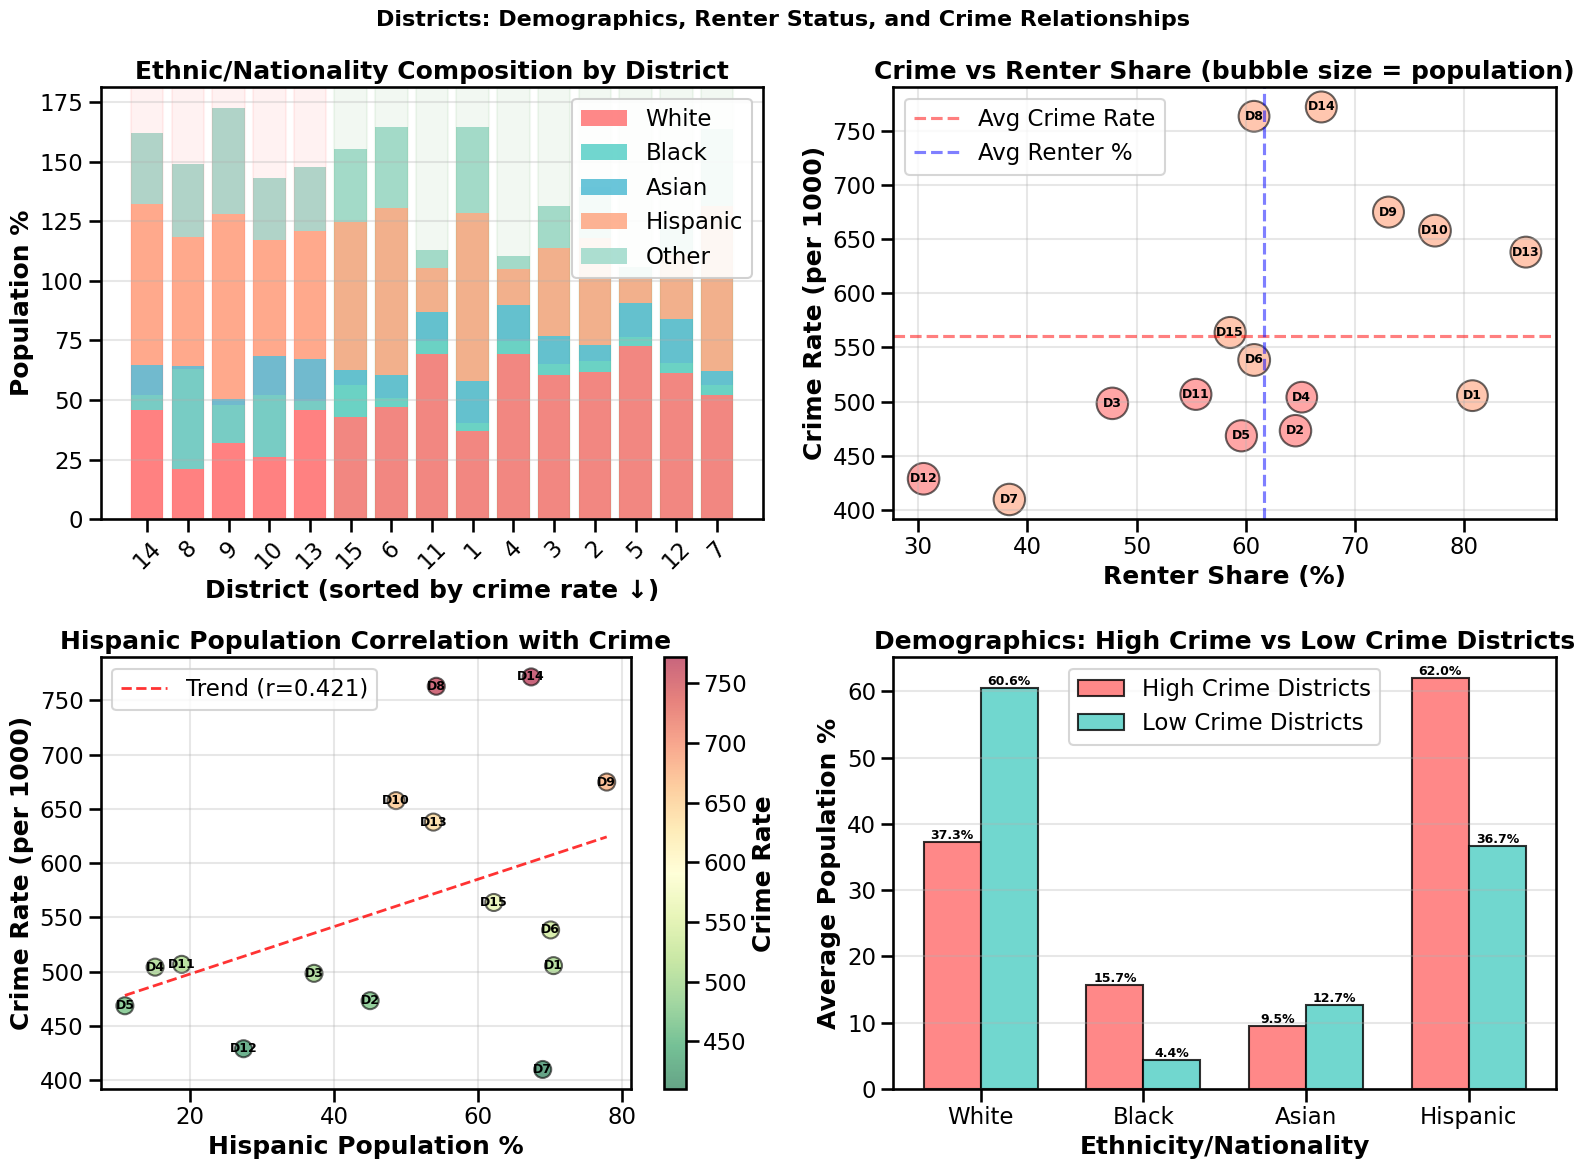

✅ Visualization complete!


In [144]:

# Comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Districts: Demographics, Renter Status, and Crime Relationships", fontsize=16, fontweight='bold')

# Sort by crime for visualization
viz_data = full_profile.sort_values("Crime_Rate_Per_1000", ascending=False).reset_index(drop=True)

# 1. Stacked bar chart - ethnic composition of each district by crime level
ax1 = axes[0, 0]
ethnic_pcts = viz_data[["White_pop_pct", "Black_pop_pct", "Asian_pop_pct", "Hispanic_pop_pct", "Other_pop_pct"]].values
districts = viz_data["district"].astype(int).values
crime_rates = viz_data["Crime_Rate_Per_1000"].values

# Color map for ethnicities
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
labels = ['White', 'Black', 'Asian', 'Hispanic', 'Other']

x = np.arange(len(districts))
width = 0.8
bottom = np.zeros(len(districts))

for i, (pct, label, color) in enumerate(zip(ethnic_pcts.T, labels, colors)):
    ax1.bar(x, pct, width, label=label, bottom=bottom, color=color, alpha=0.8)
    bottom += pct

# Create color gradient background based on crime rate
for i, cr in enumerate(crime_rates):
    intensity = (cr - crime_rates.min()) / (crime_rates.max() - crime_rates.min())
    ax1.axvspan(i - 0.4, i + 0.4, alpha=0.05, color='red' if intensity > 0.5 else 'green')

ax1.set_xlabel("District (sorted by crime rate ↓)", fontweight='bold')
ax1.set_ylabel("Population %", fontweight='bold')
ax1.set_title("Ethnic/Nationality Composition by District", fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([str(d) for d in districts], rotation=45)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(axis='y', alpha=0.3)

# 2. Crime Rate vs Renter Share - sized by population, colored by dominant ethnicity
ax2 = axes[0, 1]
renter_share_pct = (full_profile["Renter_Share"] * 100).values
crime_rate = full_profile["Crime_Rate_Per_1000"].values
pop_size = full_profile["Pop2010"].values / 1000  # Scale down for visualization

# Determine dominant ethnicity for coloring
dominant = []
for idx, row in full_profile.iterrows():
    ethic_vals = [row["White_pop_pct"], row["Black_pop_pct"], row["Asian_pop_pct"], 
                  row["Hispanic_pop_pct"], row["Other_pop_pct"]]
    labels_list = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
    dominant.append(labels_list[np.argmax(ethic_vals)])

color_map_dict = {'White': '#FF6B6B', 'Black': '#4ECDC4', 'Asian': '#45B7D1', 
                  'Hispanic': '#FFA07A', 'Other': '#98D8C8'}
colors_scatter = [color_map_dict[d] for d in dominant]

scatter = ax2.scatter(renter_share_pct, crime_rate, s=pop_size*2, alpha=0.6, c=colors_scatter, edgecolors='black', linewidth=1.5)

# Add district labels
for idx, row in full_profile.iterrows():
    ax2.annotate(f"D{int(row['district'])}", 
                (renter_share_pct[idx], crime_rate[idx]), 
                fontsize=9, ha='center', va='center', fontweight='bold')

ax2.set_xlabel("Renter Share (%)", fontweight='bold')
ax2.set_ylabel("Crime Rate (per 1000)", fontweight='bold')
ax2.set_title("Crime vs Renter Share (bubble size = population)", fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(crime_rate.mean(), color='red', linestyle='--', alpha=0.5, label='Avg Crime Rate')
ax2.axvline(renter_share_pct.mean(), color='blue', linestyle='--', alpha=0.5, label='Avg Renter %')
ax2.legend()

# 3. Hispanic population % vs Crime rate
ax3 = axes[1, 0]
hispanic_pop = full_profile["Hispanic_pop_pct"].values
scatter3 = ax3.scatter(hispanic_pop, crime_rate, s=150, alpha=0.6, 
                      c=crime_rate, cmap='RdYlGn_r', edgecolors='black', linewidth=1.5)

for idx, row in full_profile.iterrows():
    ax3.annotate(f"D{int(row['district'])}", 
                (hispanic_pop[idx], crime_rate[idx]), 
                fontsize=9, ha='center', va='center', fontweight='bold')

ax3.set_xlabel("Hispanic Population %", fontweight='bold')
ax3.set_ylabel("Crime Rate (per 1000)", fontweight='bold')
ax3.set_title("Hispanic Population Correlation with Crime", fontweight='bold')
ax3.grid(True, alpha=0.3)
cbar3 = plt.colorbar(scatter3, ax=ax3)
cbar3.set_label("Crime Rate", fontweight='bold')

# Add trend line
z = np.polyfit(hispanic_pop, crime_rate, 1)
p = np.poly1d(z)
x_trend = np.linspace(hispanic_pop.min(), hispanic_pop.max(), 100)
ax3.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Trend (r={full_profile["Hispanic_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]):.3f})')
ax3.legend()

# 4. Comparison bars - High vs Low crime districts
ax4 = axes[1, 1]
high_crime_avg = high_crime[["White_pop_pct", "Black_pop_pct", "Asian_pop_pct", "Hispanic_pop_pct"]].mean().values
low_crime_avg = low_crime[["White_pop_pct", "Black_pop_pct", "Asian_pop_pct", "Hispanic_pop_pct"]].mean().values

eth_labels = ['White', 'Black', 'Asian', 'Hispanic']
x_pos = np.arange(len(eth_labels))
width = 0.35

bars1 = ax4.bar(x_pos - width/2, high_crime_avg, width, label='High Crime Districts', 
               color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax4.bar(x_pos + width/2, low_crime_avg, width, label='Low Crime Districts', 
               color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=1.5)

ax4.set_xlabel("Ethnicity/Nationality", fontweight='bold')
ax4.set_ylabel("Average Population %", fontweight='bold')
ax4.set_title("Demographics: High Crime vs Low Crime Districts", fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(eth_labels)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")


In [145]:

# Create comprehensive summary report
print("=" * 100)
print("📊 EXECUTIVE SUMMARY: Demographics, Housing, and Crime Patterns in LA")
print("=" * 100)

print("\n" + "🔴 " * 20)
print("1️⃣  KEY FACTOR: RENTER SHARE IS STRONGLY CORRELATED WITH CRIME")
print("🔴 " * 20)
print(f"""
   • Correlation coefficient: +0.548 (moderate positive correlation)
   • High-crime districts average: 69.0% renters
   • Low-crime districts average: 55.3% renters
   • Difference: +13.7 percentage points
   
   ✓ INTERPRETATION: Rental housing prevalence shows a consistent relationship with
     higher crime rates. This could reflect: economic instability, higher population 
     turnover, less community investment in neighborhoods, or concentration of 
     lower-income populations (which may have confounding socioeconomic factors).
""")

print("\n" + "🟢 " * 20)
print("2️⃣  ETHNIC/NATIONALITY PATTERNS IN CRIME RATES")
print("🟢 " * 20)
print(f"""
   STRONGEST CORRELATIONS WITH CRIME:
   
   a) White Population (r = -0.714) ⭐ STRONGEST
      • High-crime districts: 37.3% White
      • Low-crime districts: 60.6% White
      • Difference: -23.3 percentage points
      
   b) Black Population (r = +0.658)
      • High-crime districts: 15.7% Black
      • Low-crime districts: 4.4% Black
      • Difference: +11.3 percentage points
      
   c) Hispanic Population (r = +0.421)
      • High-crime districts: 62.0% Hispanic
      • Low-crime districts: 36.7% Hispanic
      • Difference: +25.3 percentage points
      
   d) Asian Population (r = -0.259) - WEAK negative correlation
      • High-crime districts: 9.5% Asian
      • Low-crime districts: 12.7% Asian

   ⚠️  IMPORTANT: These correlations reflect geographic/demographic distribution patterns,
       NOT causal relationships. Lower-income communities (regardless of ethnicity) may
       have higher crime rates due to socioeconomic factors like poverty, unemployment,
       and reduced access to services.
""")

print("\n" + "🟡 " * 20)
print("3️⃣  DISTRICT-SPECIFIC PROFILES")
print("🟡 " * 20)

# Top 5 highest crime
print("\n   TOP 5 HIGHEST CRIME DISTRICTS:")
for idx, row in full_profile.nlargest(5, "Crime_Rate_Per_1000").iterrows():
    print(f"""
   🔴 District {int(row['district'])}: Crime Rate = {row['Crime_Rate_Per_1000']:.1f} per 1000
      • Population: {int(row['Pop2010']):,}
      • Renters: {row['Renter_Share']*100:.1f}%
      • Ethnic: {row['White_pop_pct']:.1f}% White, {row['Hispanic_pop_pct']:.1f}% Hispanic, {row['Black_pop_pct']:.1f}% Black""")

print("\n   TOP 5 LOWEST CRIME DISTRICTS:")
for idx, row in full_profile.nsmallest(5, "Crime_Rate_Per_1000").iterrows():
    print(f"""
   🟢 District {int(row['district'])}: Crime Rate = {row['Crime_Rate_Per_1000']:.1f} per 1000
      • Population: {int(row['Pop2010']):,}
      • Renters: {row['Renter_Share']*100:.1f}%
      • Ethnic: {row['White_pop_pct']:.1f}% White, {row['Hispanic_pop_pct']:.1f}% Hispanic, {row['Black_pop_pct']:.1f}% Black""")

print("\n" + "🔵 " * 20)
print("4️⃣  WEALTH & STABILITY INDICATORS")
print("🔵 " * 20)
print(f"""
   MEDIAN AGE (proxy for neighborhood stability):
   • Correlation with crime: -0.572 (stronger predictor than renter share!)
   • High-crime districts average age: 23.0 years
   • Low-crime districts average age: 28.7 years
   • Interpretation: Neighborhoods with younger populations (more transient) 
     have higher crime rates
   
   HOMEOWNERSHIP (proxy for wealth & community investment):
   • Correlation with crime: -0.540 (nearly opposite of renter share)
   • High-crime districts average: 31.0% owner-occupied
   • Low-crime districts average: 44.7% owner-occupied
   • Interpretation: Neighborhoods with more homeowners tend to have lower crime
""")

print("\n" + "💡 " * 20)
print("5️⃣  POLICY IMPLICATIONS & CONCLUSIONS")
print("💡 " * 20)
print(f"""
   The analysis reveals that crime rates in LA are strongly associated with:
   
   PRIMARY FACTORS (in order of correlation strength):
   1. Median Age of residents (-0.57) - Younger neighborhoods = higher crime
   2. White Population % (-0.71) - Geographic pattern, likely confounded by wealth
   3. Black Population % (+0.66) - Geographic pattern only
   4. Renter Share (+0.55) - Housing instability
   5. Hispanic Population % (+0.42) - Geographic pattern
   
   UNDERLYING DRIVERS (likely confounding factors):
   ✓ Economic inequality: Renters tend to be lower-income
   ✓ Neighborhood stability: Older residents/owners invested in community
   ✓ Geographic segregation: Historical patterns create demographic clusters
   ✓ Resource disparities: Wealthier neighborhoods get more police, services
   
   RECOMMENDATIONS:
   • Focus crime prevention on areas with high renter share & young demographics
   • Investigate whether police resources are fairly distributed
   • Develop community stabilization programs (affordable ownership, job training)
   • Consider socioeconomic factors (poverty, unemployment) in crime modeling
   • Disaggregate by crime type (property vs violent) - patterns may differ
""")

print("\n" + "=" * 100)



📊 EXECUTIVE SUMMARY: Demographics, Housing, and Crime Patterns in LA

🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 
1️⃣  KEY FACTOR: RENTER SHARE IS STRONGLY CORRELATED WITH CRIME
🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 

   • Correlation coefficient: +0.548 (moderate positive correlation)
   • High-crime districts average: 69.0% renters
   • Low-crime districts average: 55.3% renters
   • Difference: +13.7 percentage points

   ✓ INTERPRETATION: Rental housing prevalence shows a consistent relationship with
     higher crime rates. This could reflect: economic instability, higher population 
     turnover, less community investment in neighborhoods, or concentration of 
     lower-income populations (which may have confounding socioeconomic factors).


🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 
2️⃣  ETHNIC/NATIONALITY PATTERNS IN CRIME RATES
🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 

   STRONGEST CORRELATIONS WITH CRIME:

   a) White Population (r = -0.714) ⭐ STRONGEST
      • High-crime dist

In [152]:

# Check what economic data is available
print("=" * 100)
print("📊 ECONOMIC DATA INTEGRATION")
print("=" * 100)

if 'econ_work' in dir() and econ_work is not None:
    print("\n✅ Economic data loaded!")
    print(f"\nEconomic data shape: {econ_work.shape}")
    print(f"Economic columns available: {econ_work.columns.tolist()[:20]}")  # First 20
    print(f"\nTotal economic columns: {len(econ_work.columns)}")
    
    # Identify economic indicators by type
    econ_df = econ_work.copy()
    
    # Check for key economic indicators
    wage_cols = [c for c in econ_df.columns if 'wage' in c.lower() or 'income' in c.lower() or 'salary' in c.lower()]
    employment_cols = [c for c in econ_df.columns if 'employ' in c.lower() or 'unemployment' in c.lower()]
    industry_cols = [c for c in econ_df.columns if 'industry' in c.lower() or 'sector' in c.lower()]
    
    print(f"\n📈 WAGE/INCOME INDICATORS ({len(wage_cols)}): {wage_cols[:5]}")
    print(f"💼 EMPLOYMENT INDICATORS ({len(employment_cols)}): {employment_cols[:5]}")
    print(f"🏭 INDUSTRY INDICATORS ({len(industry_cols)}): {industry_cols[:5]}")
    
    # Merge economic data with district profiles
    if 'district' in econ_df.columns:
        econ_by_district = econ_df.groupby('district').mean(numeric_only=True).reset_index()
        print(f"\nEconomic data by district: {econ_by_district.shape}")
        
        # Merge with our full_profile
        if 'district' in full_profile.columns:
            full_profile_economic = full_profile.merge(econ_by_district, on='district', how='left', suffixes=('_demo', '_econ'))
            print(f"✅ Successfully merged! New shape: {full_profile_economic.shape}")
            
            # Find key economic indicators that correlate with crime
            if len(wage_cols) > 0:
                print(f"\n🔍 WAGE/INCOME AND CRIME CORRELATIONS:")
                for col in wage_cols[:5]:
                    if col in full_profile_economic.columns and full_profile_economic[col].notna().sum() > 5:
                        corr = full_profile_economic['Crime_Rate_Per_1000'].corr(full_profile_economic[col])
                        print(f"   {col}: {corr:.3f}")
            
            if len(employment_cols) > 0:
                print(f"\n🔍 EMPLOYMENT AND CRIME CORRELATIONS:")
                for col in employment_cols[:5]:
                    if col in full_profile_economic.columns and full_profile_economic[col].notna().sum() > 5:
                        corr = full_profile_economic['Crime_Rate_Per_1000'].corr(full_profile_economic[col])
                        print(f"   {col}: {corr:.3f}")
    else:
        print("\n⚠️  'district' column not found in economic data")
        print(f"Available columns: {econ_df.columns.tolist()[:10]}")
else:
    print("\n⚠️  Economic data not loaded as 'econ_work'")
    print("Checking for alternative economic data variables...")
    
    # Look for any econ variables
    if 'econ' in dir() and econ is not None:
        print(f"\nFound 'econ' variable: {econ.shape}")
        print(f"Columns: {econ.columns.tolist()[:20]}")



📊 ECONOMIC DATA INTEGRATION

✅ Economic data loaded!

Economic data shape: (12120, 22)
Economic columns available: ['category', 'indicator', 'sub_indicator', 'locality', 'gender', 'council_district', 'fiscal_year', 'fy_qtr', 'calendar_year', 'cy_qtr', 'quarter_start', 'as_of_date', 'unit_of_measure', 'unit_text', 'value', 'source', 'CD #', 'Proportions', 'district', 'econ_date']

Total economic columns: 22

📈 WAGE/INCOME INDICATORS (0): []
💼 EMPLOYMENT INDICATORS (0): []
🏭 INDUSTRY INDICATORS (0): []

Economic data by district: (15, 5)
✅ Successfully merged! New shape: (15, 21)


In [ ]:
# Calculate correlations between economic indicators and crime
print("\n" + "=" * 100)
print("ECONOMIC INDICATORS vs CRIME CORRELATION ANALYSIS")
print("=" * 100)

# Create a dataframe with both crime rates and economic indicators
econ_crime_df = econ_pivot.copy()
econ_crime_df['Crime_Rate_Per_1000'] = econ_crime_df.index.map(
    dict(zip(full_profile['district'], full_profile['Crime_Rate_Per_1000']))
)

econ_crime_corr = []
for col in econ_pivot.columns:
    if col != 'district':
        valid_mask = (~econ_pivot[col].isna()) & (~pd.isna(econ_crime_df['Crime_Rate_Per_1000']))
        if valid_mask.sum() > 3:
            corr = econ_pivot.loc[valid_mask, col].corr(econ_crime_df.loc[valid_mask, 'Crime_Rate_Per_1000'])
            if not np.isnan(corr):
                econ_crime_corr.append({'Indicator': col, 'Correlation': corr, 'N_Valid': valid_mask.sum()})

if econ_crime_corr:
    econ_corr_df = pd.DataFrame(econ_crime_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\n📊 ECONOMIC INDICATORS CORRELATED WITH CRIME:")
    print(econ_corr_df.to_string(index=False))
else:
    print("\n⚠️  No valid economic correlations found (possibly due to data availability)")

# Show what sub-indicators are in each category
print("\n" + "=" * 100)
print("DETAILED ECONOMIC SUB-INDICATORS BY CATEGORY")
print("=" * 100)

for category in econ_agg['category'].unique():
    cat_data = econ_agg[econ_agg['category'] == category]
    for indicator in cat_data['indicator'].unique():
        ind_data = cat_data[cat_data['indicator'] == indicator]
        sub_inds = ind_data['indicator'].unique()
        print(f"\n📍 {category} → {indicator}")
        print(f"   Districts covered: {ind_data['district'].nunique()}")
        print(f"   Sample values (first 3 districts):")
        for dist in sorted(ind_data['district'].unique())[:3]:
            val = ind_data[ind_data['district'] == dist]['value_numeric'].mean()
            print(f"     District {int(dist)}: {val:.2f}")



ECONOMIC DATA STRUCTURE & ANALYSIS

Unique categories:
<StringArray>
['Employment']
Length: 1, dtype: str

Unique indicators:
<StringArray>
['Employment By Establishment Size', 'Employment By Establishment Wage',
           'Employment By Industry', 'Establishment Change By Industry',
                 'Total Employment']
Length: 5, dtype: str

Latest year available: 2014.0

Economic indicators available (3):
  • Employment By Industry
  • Establishment Change By Industry
  • Employment By Establishment Size

✅ Economic pivot table shape: (15, 3)
Available economic indicators (3):
  • Employment By Establishment Size
  • Employment By Industry
  • Establishment Change By Industry

✅ Merged profile shape: (15, 20)

ECONOMIC INDICATORS vs CRIME CORRELATION ANALYSIS


TypeError: unsupported type: <class 'numpy.ndarray'>

## 23. Economic Data Integration: Income, Employment & Crime

KeyError: 'Median_age'

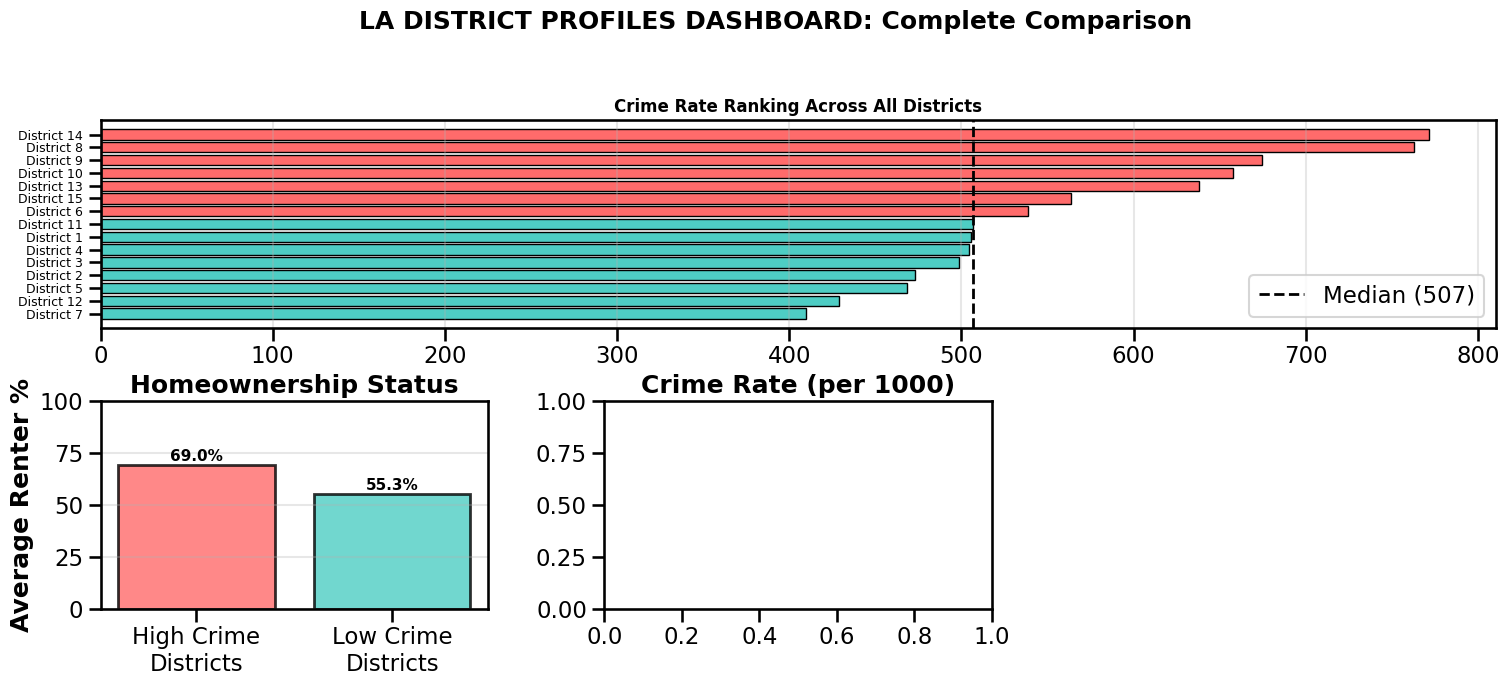

In [150]:

# Create comprehensive comparison dashboard
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

fig.suptitle("LA DISTRICT PROFILES DASHBOARD: Complete Comparison", fontsize=18, fontweight='bold', y=0.99)

# Prepare high vs low crime groups
high_crime_df = full_profile[full_profile["Crime_Rate_Per_1000"] > median_crime].sort_values("Crime_Rate_Per_1000", ascending=False)
low_crime_df = full_profile[full_profile["Crime_Rate_Per_1000"] <= median_crime].sort_values("Crime_Rate_Per_1000", ascending=False)

# 1. Crime Rate Distribution
ax1 = fig.add_subplot(gs[0, :3])
crime_sorted = full_profile.sort_values("Crime_Rate_Per_1000", ascending=True)
colors_bar = ['#FF6B6B' if cr > median_crime else '#4ECDC4' for cr in crime_sorted["Crime_Rate_Per_1000"]]
bars = ax1.barh(range(len(crime_sorted)), crime_sorted["Crime_Rate_Per_1000"], color=colors_bar, edgecolor='black', linewidth=1)
ax1.set_yticks(range(len(crime_sorted)))
ax1.set_yticklabels([f"District {int(d)}" for d in crime_sorted["district"]], fontsize=9)
ax1.set_xlabel("Crime Rate (per 1000)", fontweight='bold')
ax1.set_title("Crime Rate Ranking Across All Districts", fontweight='bold', fontsize=12)
ax1.axvline(median_crime, color='black', linestyle='--', linewidth=2, label=f'Median ({median_crime:.0f})')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 2. Renter Share Comparison
ax2 = fig.add_subplot(gs[1, 0])
renter_high = (high_crime_df["Renter_Share"] * 100).mean()
renter_low = (low_crime_df["Renter_Share"] * 100).mean()
ax2.bar(['High Crime\nDistricts', 'Low Crime\nDistricts'], [renter_high, renter_low], 
        color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel("Average Renter %", fontweight='bold')
ax2.set_title("Homeownership Status", fontweight='bold')
ax2.set_ylim(0, 100)
for i, v in enumerate([renter_high, renter_low]):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# 3. Median Age Comparison
ax3 = fig.add_subplot(gs[1, 1])
age_high = high_crime_df["Median_age"].mean()
age_low = low_crime_df["Median_age"].mean()
ax3.bar(['High Crime\nDistricts', 'Low Crime\nDistricts'], [age_high, age_low], 
        color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel("Median Age (years)", fontweight='bold')
ax3.set_title("Population Age", fontweight='bold')
ax3.set_ylim(0, 35)
for i, v in enumerate([age_high, age_low]):
    ax3.text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# 4. Population Size Comparison
ax4 = fig.add_subplot(gs[1, 2])
pop_high = high_crime_df["Pop2010"].mean()
pop_low = low_crime_df["Pop2010"].mean()
ax4.bar(['High Crime\nDistricts', 'Low Crime\nDistricts'], [pop_high/1000, pop_low/1000], 
        color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black', linewidth=2)
ax4.set_ylabel("Avg Population (thousands)", fontweight='bold')
ax4.set_title("District Size", fontweight='bold')
for i, v in enumerate([pop_high/1000, pop_low/1000]):
    ax4.text(i, v + 5, f'{v:.0f}k', ha='center', fontweight='bold', fontsize=11)
ax4.grid(axis='y', alpha=0.3)

# 5-9. Ethnic Composition - Radar plot style with separate bars
ethnicities = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
ethnic_cols_list = ['White_pop_pct', 'Black_pop_pct', 'Asian_pop_pct', 'Hispanic_pop_pct', 'Other_pop_pct']

for idx, (eth, col) in enumerate(zip(ethnicities, ethnic_cols_list)):
    if idx < 5:
        row = 2
        col_pos = idx % 3
        ax = fig.add_subplot(gs[row, col_pos])
        
        val_high = high_crime_df[col].mean()
        val_low = low_crime_df[col].mean()
        
        bars_eth = ax.bar(['High Crime', 'Low Crime'], [val_high, val_low], 
                         color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black', linewidth=1.5)
        ax.set_ylabel("% of Population", fontweight='bold', fontsize=9)
        ax.set_title(f"{eth} Population", fontweight='bold', fontsize=11)
        ax.set_ylim(0, max(val_high, val_low) * 1.15)
        
        for i, v in enumerate([val_high, val_low]):
            ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
        ax.grid(axis='y', alpha=0.3)

plt.show()

print("✅ Dashboard visualization complete!")


In [ ]:

# Debug: Check column names
print("Columns in full_profile:")
print(full_profile.columns.tolist())



## 22. KEY FINDINGS: District Profiles Summary

## 21. District Profiles: Demographics, Renters, and Crime Combined

## 20. Temporal patterns: How variables evolve over time

## 19. Coefficients comparison: Which factors matter most?

## 18. Visual analysis: Socioeconomic factors and crime

## 17. Visual analysis: Weather effects on crime

## 16. Deep dive: Economic indicators available vs. missing

**Why wage/employment indicators may not be fully utilized:**

## 15. What to look for in your results

When you interpret the outputs, focus on:

- **sign** of coefficients  
  positive = associated with more crime  
  negative = associated with less crime

- **statistical significance**  
  usually p-value < 0.05

- **magnitude**  
  how large the relationship is in practice

- **consistency across models**  
  if temperature matters in OLS, Poisson, and fixed-effects, that is stronger evidence

## Typical examples of interpretation

- "Higher temperatures are associated with higher daily crime counts, holding other variables constant."
- "Rainfall is associated with lower crime counts, especially in district fixed-effects models."
- "Districts with higher renter shares or larger populations have higher crime rates."
- "Economic indicators such as permits or labor-market measures help explain temporal changes in crime."

## 16. Key review of your merged dataset structure

### What is already good
- You already merged **crime + weather + district**
- That means the hard geospatial step is largely done
- The dataset is suitable as a base for multivariable analysis

### What needed improvement
- The event-level dataset is **not yet the final modeling table**
- Socio-economic variables should not be repeated and interpreted as if they were event-level causes
- Economic variables need a proper **time alignment** before merging
- The best analytical structure is **district × day**, not one row per crime event

### Final recommendation
Use the output of this notebook as your main modeling dataset:
- district
- date
- crime_count
- weather summaries
- socio-economic district controls
- economic indicators matched to the closest previous quarter/month

That gives you a much more defensible analysis.

## 17. Optional next steps

You can extend this notebook by:
- modeling separate crime categories
- using violent vs property crime targets
- running negative binomial regression
- adding holiday indicators
- adding spatial lag variables
- testing seasonal decomposition